# Experiment Results Analysis 

The object of this notebook is to create plots in order to test hypothesis regarding algorithm performance.

In this notebook the different executed batches of experiments will be consolidated in a unique database to analyze its results. Later, we a re going to plot heatmaps with different configurations.


## Analysis Conducted

1. Compare AUC for each algorithm in each enviroment (Comparisons are conducted across algorithms in the same environment)

2. Compare the Mean Best So Far Curve in each enviroment (Comparisons are conducted across algorithms in the same environment) with confidence intervals

3. Perform the wilcoxon Rank Sum test in each enviroment for selected pairwise comaprisons (Comparisons are conducted across algorithms in the same environment) with confidence intervals


## Algorithms to compare

1. Binary Particle Swarm Optimization - (PSO)

2. Binary Global Random Search - (Random)

3. Standard Binary Representation GA (Generic)

4. Standard Mixed Integer Representation GA (mixed_generic)

5a. Macro_Micro CX Operator GA - (macro_micro)

5b. Macro CX Operator GA - Deactivates Micro CX operator - (micro)

5c. Micro CX Operator GA - Deactivates Macro CX operator - (macro)

5d. Parents CX Operator - Uses a parent recombination CX Operator (recomb)

## 1. Library Imports

In [491]:
import pandas as pd 
import numpy as np
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import ast
from typing import List, Dict 
import re

## 2. Data Import

In [492]:
# Check wd
print(os.getcwd())



c:\Users\57305\Documents\FTZ_model_2.0\final_results\experiment


In [493]:
def load_and_concat_csv(paths: List[str], *, ignore_index: bool = True) -> pd.DataFrame:
    """
    Load multiple CSV files and concatenate them into a single DataFrame.

    Parameters
    ----------
    paths : List[str]
        List of file paths to CSV files.
    ignore_index : bool, optional
        If True, reset the index in the concatenated DataFrame. Default is True.

    Returns
    -------
    pd.DataFrame
        Concatenated DataFrame containing all CSV files.
    """
    dataframes = []
    for path in paths:
        try:
            df = pd.read_csv(path)
            df["source_file"] = path  # optional: keep track of origin
            dataframes.append(df)
            print(f"Loaded: {path} ({len(df)} rows)")
        except FileNotFoundError:
            print(f" File not found: {path}")
        except pd.errors.EmptyDataError:
            print(f" Empty file skipped: {path}")
        except Exception as e:
            print(f" Error reading {path}: {e}")

    if not dataframes:
        raise ValueError("No valid CSV files loaded.")

    combined_df = pd.concat(dataframes, ignore_index=ignore_index)
    print(f" Combined DataFrame: {combined_df.shape[0]} rows, {combined_df.shape[1]} columns")

    return combined_df

In [494]:
paths = [
    r"data_exp\experiment_final_macrmicro_mixedgeneric\experiment_final_macrmicro_mixedgeneric\results.csv",
    r"data_exp\experiment_final_nocross_jmicro_jmacro_recomb\experiment_final_nocross_jmicro_jmacro_recomb\results.csv",
    r"data_exp\final_experiment_rand_pso_gen (1)\final_experiment_rand_pso_gen\results.csv"
]


In [495]:
df_all = load_and_concat_csv(paths)

Loaded: data_exp\experiment_final_macrmicro_mixedgeneric\experiment_final_macrmicro_mixedgeneric\results.csv (32480 rows)
Loaded: data_exp\experiment_final_nocross_jmicro_jmacro_recomb\experiment_final_nocross_jmicro_jmacro_recomb\results.csv (64960 rows)
Loaded: data_exp\final_experiment_rand_pso_gen (1)\final_experiment_rand_pso_gen\results.csv (48720 rows)
 Combined DataFrame: 146160 rows, 11 columns


## 3. Clean Data 

Due to a code / paralleization mistake, some rows are duplicated

In [496]:
df_all.head()

,env_name,run,algorithm,seed,best_curve,best_value,best_genome,all_best_genomes,elapsed_sec,success,source_file
0,Linear_standard,1,macro_micro,483575,"[38.9, 39.05, 39.05, 39.2, 39.35, 39.35, 39.35...",39.35,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",81.426382,True,data_exp\experiment_final_macrmicro_mixedgener...
1,Linear_standard,11,macro_micro,1424007,"[38.75, 38.9, 38.9, 39.05, 39.05, 39.2, 39.2, ...",39.35,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",81.670461,True,data_exp\experiment_final_macrmicro_mixedgener...
2,Linear_standard,13,macro_micro,1242588,"[38.75, 38.9, 39.05, 39.05, 39.2, 39.2, 39.2, ...",39.35,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",81.777966,True,data_exp\experiment_final_macrmicro_mixedgener...
3,Linear_standard,10,macro_micro,874627,"[39.05, 39.05, 39.05, 39.2, 39.2, 39.2, 39.35,...",39.35,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",81.887681,True,data_exp\experiment_final_macrmicro_mixedgener...
4,Linear_standard,6,macro_micro,1081112,"[38.75, 38.9, 39.05, 39.05, 39.35, 39.35, 39.3...",39.35,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",82.319809,True,data_exp\experiment_final_macrmicro_mixedgener...


In [497]:
df_all.columns

Index(['env_name', 'run', 'algorithm', 'seed', 'best_curve', 'best_value',
       'best_genome', 'all_best_genomes', 'elapsed_sec', 'success',
       'source_file'],
      dtype='object')

In [498]:
import numpy as np
import pandas as pd

# Keep the row with the smallest elapsed_sec per (env_name, algorithm, seed, run)
before = len(df_all)
print(f"Total rows before removing duplicates: {before}")

df_tmp = df_all.copy()
df_tmp["elapsed_sec"] = pd.to_numeric(df_tmp.get("elapsed_sec", np.nan), errors="coerce")
df_tmp["_elapsed_sort"] = df_tmp["elapsed_sec"].fillna(np.inf)

df_analysis = (
    df_tmp
    .sort_values(["env_name", "algorithm", "seed", "run", "_elapsed_sort"],
                 ascending=[True, True, True, True, True])
    .drop_duplicates(subset=["env_name", "algorithm", "seed", "run"], keep="first")
    .drop(columns=["_elapsed_sort"])
    .reset_index(drop=True)
)

after = len(df_analysis)
print(f"Removed {before - after} duplicate rows")



Total rows before removing duplicates: 146160
Removed 136080 duplicate rows


In [499]:
df = df_analysis.copy()


def _n_pairs(g: pd.DataFrame) -> int:
   
    sub = g.dropna(subset=["seed", "run"])
    return sub.drop_duplicates(["seed", "run"]).shape[0]

summary = (
    df.groupby(["env_name", "algorithm"])
      .agg(
          n_rows=("env_name", "size"),
          n_seeds=("seed", pd.Series.nunique),   
          n_runs =("run",  pd.Series.nunique),   
      )
      .reset_index()
)


pairs = (
    df.groupby(["env_name", "algorithm"])
      .apply(_n_pairs)
      .rename("n_seed_run_pairs")
      .reset_index()
)

summary = summary.merge(pairs, on=["env_name", "algorithm"])
summary = summary.sort_values(["env_name", "algorithm"]).reset_index(drop=True)

print("Per environment × algorithm:")
print(summary.to_string(index=False))


pivot_seeds = summary.pivot(index="algorithm", columns="env_name", values="n_seeds").fillna(0).astype(int)

pivot_runs  = summary.pivot(index="algorithm", columns="env_name", values="n_runs").fillna(0).astype(int)

pivot_pairs = summary.pivot(index="algorithm", columns="env_name", values="n_seed_run_pairs").fillna(0).astype(int)

Per environment × algorithm:
                                         env_name     algorithm  n_rows  n_seeds  n_runs  n_seed_run_pairs
                             All Inputs_perturbed       generic      40       40      40                40
                             All Inputs_perturbed         macro      40       40      40                40
                             All Inputs_perturbed   macro_micro      40       40      40                40
                             All Inputs_perturbed         micro      40       40      40                40
                             All Inputs_perturbed mixed_generic      40       40      40                40
                             All Inputs_perturbed  no_crossover      40       40      40                40
                             All Inputs_perturbed           pso      40       40      40                40
                             All Inputs_perturbed        random      40       40      40                40
        

C:\Users\57305\AppData\Local\Temp\ipykernel_32372\3803810339.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_n_pairs)


In [500]:
dups = (
    df.dropna(subset=["seed", "run"])
      .duplicated(subset=["env_name", "algorithm", "seed", "run"], keep=False)
)
print(f"\nDuplicated exact rows (same env, algo, seed, run): {dups.sum()} found")



Duplicated exact rows (same env, algo, seed, run): 0 found


# Win/Loss Heat Maps

## BEST.

In [501]:
# --- Renombrar algoritmos según nuevos códigos ---
algo_map = {
    "pso": "1",
    "random": "2",
    "generic": "3",
    "mixed_generic": "4",
    "macro_micro": "5a",
    "macro": "5b",
    "micro": "5c",
    "recomb": "5d",
    "no_crossover": "5e"
}

df_analysis["algorithm"] = df_analysis["algorithm"].replace(algo_map)


In [502]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

ALPHA = 0.05
MIN_N = 39  # mínimo corridas por algoritmo en un entorno para testear

# -------- Utilidades --------
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    x_sorted, y_sorted = np.sort(x), np.sort(y)
    i = j = greater = less = 0
    nx, ny = len(x_sorted), len(y_sorted)
    while i < nx and j < ny:
        if x_sorted[i] > y_sorted[j]:
            greater += (nx - i); j += 1
        elif x_sorted[i] < y_sorted[j]:
            less += (ny - j); i += 1
        else:
            v = x_sorted[i]
            cx = 0
            while i < nx and x_sorted[i] == v:
                cx += 1; i += 1
            cy = 0
            while j < ny and y_sorted[j] == v:
                cy += 1; j += 1
    denom = nx * ny
    return np.nan if denom == 0 else (greater - less) / denom

def hodges_lehmann(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if x.size == 0 or y.size == 0: 
        return np.nan
    diffs = x[:, None] - y[None, :]
    return np.median(diffs)

def holm_bonferroni(pvals, alpha=ALPHA):
    p = pd.Series(pvals).reset_index(drop=True)
    order = p.sort_values().index.to_list()
    m = len(p); reject = pd.Series(False, index=p.index)
    passed = True
    for rank, idx in enumerate(order, start=1):
        thresh = alpha / (m - rank + 1)
        if p[idx] <= thresh and passed:
            reject[idx] = True
        else:
            passed = False
    return reject.values

# -------- Entrada y limpieza --------
if 'df_analysis' not in globals():
    raise RuntimeError("df_analysis no está definido en el notebook.")

df_wilcoxon = (
    df_analysis[["env_name", "algorithm", "best_value"]]
    .copy()
)

df_wilcoxon["best_value"] = pd.to_numeric(df_wilcoxon["best_value"], errors="coerce")
df_wilcoxon = df_wilcoxon.dropna(subset=["best_value"])

# Descriptivos (útil para inspección)
desc = (
    df_wilcoxon
    .groupby(["env_name", "algorithm"])["best_value"]
    .agg(n="count", mean="mean", std="std", median="median",
         q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
    .reset_index()
)

# -------- Pares a testear (A != B) --------
algos_present = sorted(df_wilcoxon["algorithm"].dropna().unique().tolist())
pairs = [(a1, a2) for a1 in algos_present for a2 in algos_present if a1 != a2]

print("Comparaciones que se harán (dirigidas, H1: A > B):")
for a1, a2 in pairs:
    print(f"  {a1} > {a2}")

# -------- Tests por entorno --------
rows = []
for env in df_wilcoxon["env_name"].unique():
    env_df = df_wilcoxon[df_wilcoxon["env_name"] == env]
    algos_env = set(env_df["algorithm"].unique())

    env_tests = []
    for a1, a2 in pairs:
        if a1 not in algos_env or a2 not in algos_env:
            continue
        v1 = env_df.loc[env_df["algorithm"] == a1, "best_value"].astype(float).values
        v2 = env_df.loc[env_df["algorithm"] == a2, "best_value"].astype(float).values
        if len(v1) < MIN_N or len(v2) < MIN_N:
            continue
        U, p = mannwhitneyu(v1, v2, alternative="greater")  # H1: a1 > a2
        env_tests.append((a1, a2, U, p, cliffs_delta(v1, v2), hodges_lehmann(v1, v2), len(v1), len(v2)))

    if env_tests:
        tmp = pd.DataFrame(env_tests, columns=["algorithm_1","algorithm_2","U","p_value","cliffs_delta","HL_diff","n1","n2"])
        tmp["reject_H0_Holm"] = holm_bonferroni(tmp["p_value"].values, alpha=ALPHA)
        tmp["reject_H0_raw"]  = tmp["p_value"] < ALPHA
        tmp.insert(0, "env_name", env)
        rows.append(tmp)

df_mannwhitney = (
    pd.concat(rows, ignore_index=True)
    if rows else
    pd.DataFrame(columns=["env_name","algorithm_1","algorithm_2","U","p_value","cliffs_delta","HL_diff","n1","n2","reject_H0_Holm","reject_H0_raw"])
)

# -------- Resúmenes --------
summary_holm = (
    df_mannwhitney
    .groupby(["algorithm_1", "algorithm_2"])["reject_H0_Holm"]
    .sum()
    .reset_index()
    .rename(columns={"reject_H0_Holm": "envs_where_a1_significantly_better_Holm"})
    .sort_values(["envs_where_a1_significantly_better_Holm","algorithm_1","algorithm_2"],
                 ascending=[False, True, True])
)

summary_raw = (
    df_mannwhitney
    .groupby(["algorithm_1", "algorithm_2"])["reject_H0_raw"]
    .sum()
    .reset_index()
    .rename(columns={"reject_H0_raw": "envs_where_a1_significantly_better_raw"})
    .sort_values(["envs_where_a1_significantly_better_raw","algorithm_1","algorithm_2"],
                 ascending=[False, True, True])
)

# -------- Salidas legibles --------
print("\n📊 Descriptivos por entorno × algoritmo (best_value):")
print(desc.head(20).to_string(index=False))

print("\n📄 Resultados detallados por entorno (Mann–Whitney unilateral, A > B):")
print(df_mannwhitney.head(40).to_string(index=False))

print("\n✅ Resumen (conteo de entornos con A ≻ B) con Holm–Bonferroni:")
print(summary_holm.to_string(index=False))

print("\n(Referencia) Resumen sin corrección múltiple:")
print(summary_raw.to_string(index=False))


Comparaciones que se harán (dirigidas, H1: A > B):
  1 > 2
  1 > 3
  1 > 4
  1 > 5a
  1 > 5b
  1 > 5c
  1 > 5d
  1 > 5e
  2 > 1
  2 > 3
  2 > 4
  2 > 5a
  2 > 5b
  2 > 5c
  2 > 5d
  2 > 5e
  3 > 1
  3 > 2
  3 > 4
  3 > 5a
  3 > 5b
  3 > 5c
  3 > 5d
  3 > 5e
  4 > 1
  4 > 2
  4 > 3
  4 > 5a
  4 > 5b
  4 > 5c
  4 > 5d
  4 > 5e
  5a > 1
  5a > 2
  5a > 3
  5a > 4
  5a > 5b
  5a > 5c
  5a > 5d
  5a > 5e
  5b > 1
  5b > 2
  5b > 3
  5b > 4
  5b > 5a
  5b > 5c
  5b > 5d
  5b > 5e
  5c > 1
  5c > 2
  5c > 3
  5c > 4
  5c > 5a
  5c > 5b
  5c > 5d
  5c > 5e
  5d > 1
  5d > 2
  5d > 3
  5d > 4
  5d > 5a
  5d > 5b
  5d > 5c
  5d > 5e
  5e > 1
  5e > 2
  5e > 3
  5e > 4
  5e > 5a
  5e > 5b
  5e > 5c
  5e > 5d

📊 Descriptivos por entorno × algoritmo (best_value):
               env_name algorithm  n     mean      std  median      q25      q75
   All Inputs_perturbed         1 40 357.4500 0.000000  357.45 357.4500 357.4500
   All Inputs_perturbed         2 40 356.8425 0.320366  356.85 356.6625 357.0

## Heat Map. Holm Number of Wins with all algorithms. Best fitness

## 7X7, No random

### All enviromments

In [503]:
def build_win_matrix(summary_holm, algo_order):
    """
    M[A,B] = cuántas veces A gana significativamente a B.
    Mantiene ceros reales.
    Solo la diagonal es NaN.
    """
    mat = pd.DataFrame(0, index=algo_order, columns=algo_order, dtype=float)

    for _, row in summary_holm.iterrows():
        a1 = row["algorithm_1"]
        a2 = row["algorithm_2"]
        v  = float(row["envs_where_a1_significantly_better_Holm"])

        if a1 in algo_order and a2 in algo_order:
            mat.loc[a1, a2] = v

    np.fill_diagonal(mat.values, np.nan)
    return mat




In [504]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# ============================================================
# PALETAS
# ============================================================
colors = {
    "main":   ["#F56E5F", "#E9F8A6", "#2ECC71"], 
    "wins":   ["#E8F8F5", "#27AE60"],             
    "losses": ["#FDEDEC", "#F56E5F"],             
}

cmap_main   = LinearSegmentedColormap.from_list("main",   colors["main"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   colors["wins"])
cmap_losses = LinearSegmentedColormap.from_list("losses", colors["losses"])

# ============================================================
# MATRIZ A GANA A B
# ============================================================
def build_win_matrix(summary_holm, algo_order):
    """
    Construye matriz M[A,B] donde M[A,B] = # de entornos donde A gana a B.
    Preserva ceros. Solo la diagonal se pone como NaN.
    """
    mat = pd.DataFrame(0, index=algo_order, columns=algo_order, dtype=float)

    for _, row in summary_holm.iterrows():
        a1 = row["algorithm_1"]
        a2 = row["algorithm_2"]
        v  = float(row["envs_where_a1_significantly_better_Holm"])

        if a1 in algo_order and a2 in algo_order:
            mat.loc[a1, a2] = v

    np.fill_diagonal(mat.values, np.nan)
    return mat


# ============================================================
# HEATMAP (versión corregida)
# ============================================================
def _plot_heatmap_with_totals_clean(mat, title):

    # Totales por fila y columna
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(2, 3, width_ratios=[20, 0.8, 2.2],
                   height_ratios=[20, 2.2], figure=fig)

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # Heatmap principal
    im = ax_main.imshow(mat.values, aspect="auto",
                        interpolation="nearest", cmap=cmap_main)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)
    cbar.set_label("# environments A ≻ B (Holm)")

    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: escribir valores incluso si val == 0 ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                ax_main.text(j, i, f"{int(val)}",
                             ha="center", va="center",
                             fontsize=9, color="#1C1C1C")

    # Columna Wins
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold",
                             fontsize=10, rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, f"{int(v)}", ha="center", va="center")

    for sp in ax_wins.spines.values(): sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # Fila Losses
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold", fontsize=10)

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, f"{int(v)}", ha="center", va="center")

    for sp in ax_losses.spines.values(): sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # Separadores
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

    for sp in ax_main.spines.values(): sp.set_visible(False)

    plt.tight_layout()
    plt.show()


In [505]:
ALGO_ORDER = ["1", "3", "4", "5a", "5b", "5c", "5d", "5e"]
win_mat = build_win_matrix(summary_holm, ALGO_ORDER)

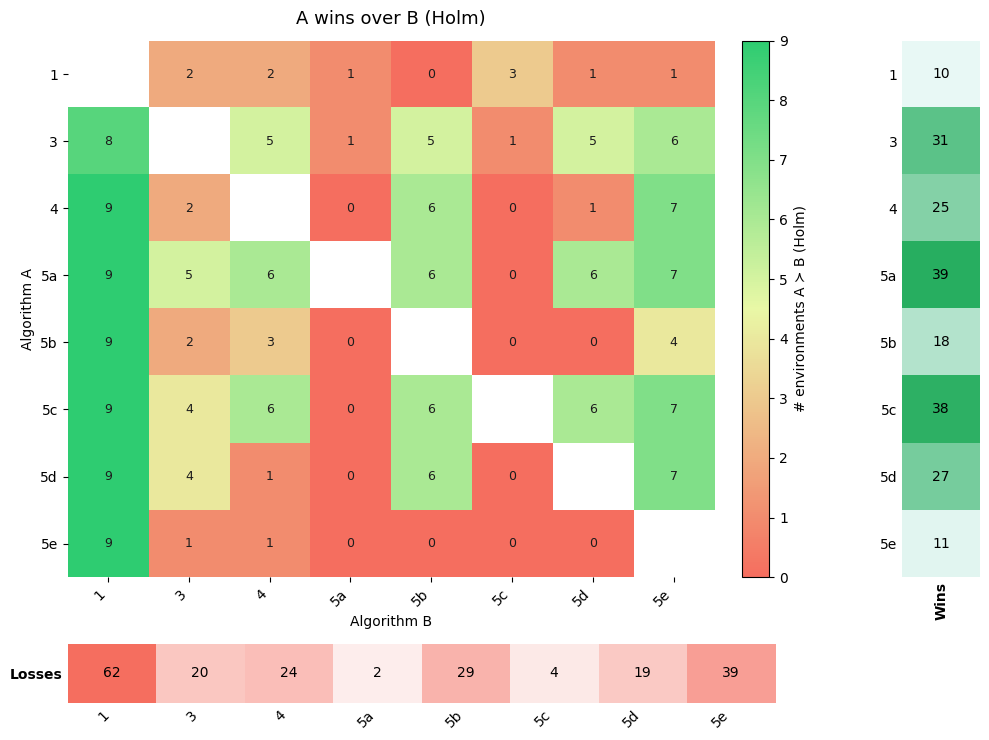

In [506]:
_plot_heatmap_with_totals_clean(win_mat, "A wins over B (Holm)")


In [507]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# Paletas (las “bonitas”)
cmap_main   = LinearSegmentedColormap.from_list("green_red", ["#E9FFDE", "#7EE6A7", "#27AE60"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   ["#CDFADF", "#8ECEA8", "#27AE60"])
cmap_losses = LinearSegmentedColormap.from_list("losses", ["#F8DBD9", "#FF796A", "#F15746"])


def _plot_heatmap_green(mat, title):
    # Totales
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    # Normalizador independiente
    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(
        2, 3,
        width_ratios=[20, 0.8, 2.2],
        height_ratios=[20, 2.2],
        figure=fig
    )

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # === Heatmap principal ===
    im = ax_main.imshow(mat.values, aspect="auto", interpolation="nearest", cmap=cmap_main)

    # === Colorbar al lado de Wins ===
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_wins)
    cax = divider.append_axes("right", size="7%", pad=0.1)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("# environments A ≻ B (Holm)")

    # Etiquetas
    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: mostrar ceros correctamente ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):          # <-- CORREGIDO
                ax_main.text(
                    j, i, f"{int(val)}",
                    ha="center", va="center",
                    fontsize=9, color="#1C1C1C"
                )

    # === Sección WINS ===
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", interpolation="nearest", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold", rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, str(int(v)), ha="center", va="center")

    for sp in ax_wins.spines.values():
        sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # === Sección LOSSES ===
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", interpolation="nearest", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold")

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, str(int(v)), ha="center", va="center")

    for sp in ax_losses.spines.values():
        sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # === Separadores blancos ===
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([])
        ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)

    # Sin bordes
    for sp in ax_main.spines.values():
        sp.set_visible(False)

    plt.tight_layout()
    plt.show()


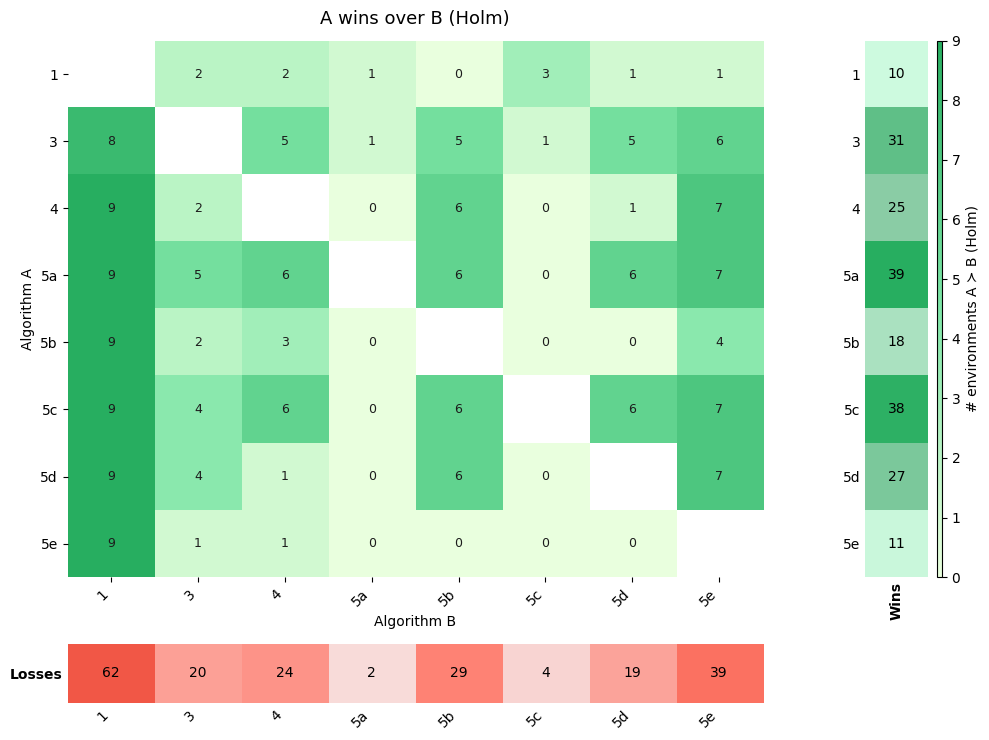

In [508]:
_plot_heatmap_green(win_mat, "A wins over B (Holm)")


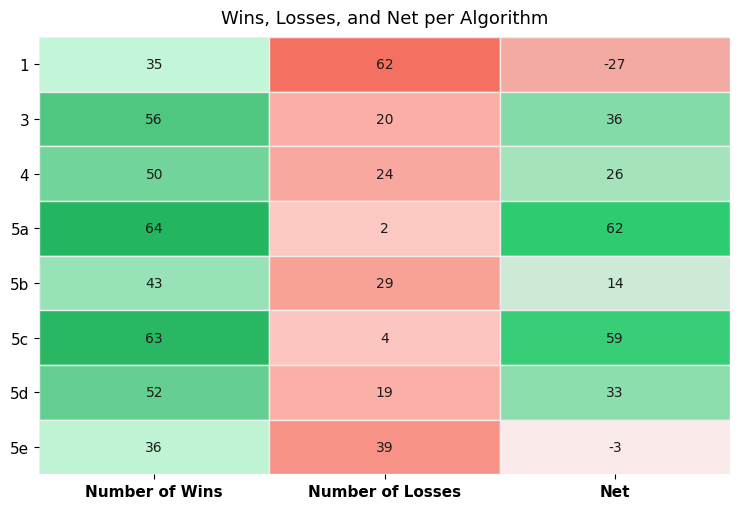

In [509]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# --- Mapeo y orden fijo (SIN el algoritmo 2) ---
algo_map = {
    "pso": "1", "random": "2", "generic": "3", "mixed_generic": "4",
    "macro_micro": "5a", "macro": "5b", "micro": "5c",
    "recomb": "5d", "no_crossover": "5e"
}
ALGO_ORDER = ALGO_ORDER

def _normalize_summary_df(obj):
    df = obj.copy()
    # Detectar nombres posibles y normalizar columnas
    if {"algorithm_1","algorithm_2","envs_where_a1_significantly_better_Holm"} <= set(df.columns):
        df = df.rename(columns={
            "algorithm_1":"A","algorithm_2":"B",
            "envs_where_a1_significantly_better_Holm":"count"
        })
    elif {"Algorithm A","Algorithm B","Envs where A ≻ B (Holm)"} <= set(df.columns):
        df = df.rename(columns={
            "Algorithm A":"A","Algorithm B":"B","Envs where A ≻ B (Holm)":"count"
        })
    df = df[["A","B","count"]].copy()
    df["A"] = df["A"].replace(algo_map)
    df["B"] = df["B"].replace(algo_map)
    df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(0).astype(int)
    return df

def _compute_wins_losses(df_norm):
    wins = df_norm.groupby("A")["count"].sum()
    losses = df_norm.groupby("B")["count"].sum()
    algos = [a for a in ALGO_ORDER if a in set(df_norm["A"]).union(df_norm["B"])]
    tbl = pd.DataFrame({
        "Algorithm": algos,
        "Number of Wins": [wins.get(a, 0) for a in algos],
        "Number of Losses": [losses.get(a, 0) for a in algos],
    })
    tbl["Net"] = tbl["Number of Wins"] - tbl["Number of Losses"]
    return tbl

def _plot_wins_losses_net_table(summary):
    # Datos columna a columna
    wins = summary["Number of Wins"].to_numpy()
    losses = summary["Number of Losses"].to_numpy()
    net = summary["Net"].to_numpy()

    # Normalizaciones independientes
    def norm01(x):
        x = x.astype(float)
        xmin, xmax = np.min(x), np.max(x)
        return np.zeros_like(x) if xmax == xmin else (x - xmin) / (xmax - xmin)

    wins_n = norm01(wins)
    losses_n = norm01(losses)

    # Net centrado en 0 con rango simétrico
    net_abs = max(abs(net.min()), abs(net.max()))
    net_norm = TwoSlopeNorm(vmin=-net_abs, vcenter=0.0, vmax=net_abs)

    # Colormaps (agradables y consistentes con tu otro heatmap)
    cmap_wins   = LinearSegmentedColormap.from_list("white_green", ["#C3F5D8", "#24B560"])
    cmap_losses = LinearSegmentedColormap.from_list("white_red",   ["#FCC8C2", "#F47162"])
    cmap_net    = LinearSegmentedColormap.from_list("gyr", ["#E74C3C", "#FBF3F3", "#2ECC71"])

    wins_rgba   = cmap_wins(wins_n)
    losses_rgba = cmap_losses(losses_n)
    net_rgba    = cmap_net(net_norm(net))

    # Matriz RGBA (filas = algoritmos, columnas = 3)
    colors = np.stack([wins_rgba, losses_rgba, net_rgba], axis=1)  # (n, 3, 4)

    # Dibujo
    n = len(summary)
    fig, ax = plt.subplots(figsize=(7.5, 0.65 * n))
    ax.set_facecolor("white")

    # Encabezados de columnas
    col_labels = ["Number of Wins", "Number of Losses", "Net"]
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(col_labels, fontsize=11, fontweight="bold")
    ax.set_yticks(np.arange(n))
    ax.set_yticklabels(summary["Algorithm"], fontsize=11)

    # Celdas coloreadas con bordes sutiles
    for i in range(n):
        for j in range(3):
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                 facecolor=colors[i, j], edgecolor="#EEEEEE", lw=1.0)
            ax.add_patch(rect)
            val = summary.iloc[i, j+1]  # +1 para saltar "Algorithm"
            ax.text(j, i, f"{val}", ha="center", va="center", fontsize=10, color="#1B1B1B")

    # Estética tipo tabla
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(n-0.5, -0.5)  # invertir eje Y para que la primera fila quede arriba
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

    ax.set_title("Wins, Losses, and Net per Algorithm", fontsize=13, pad=10)
    plt.tight_layout()
    plt.show()

# --- Ejecutar ---
df_best_norm = _normalize_summary_df(summary_holm)
summary_table = _compute_wins_losses(df_best_norm)
_plot_wins_losses_net_table(summary_table)


In [510]:
def build_net_from_summary(summary_holm):
    """
    Construye matriz cuadrada M donde:
        M[A,B] = (# entornos A > B) - (# entornos B > A)
    """
    algos = sorted(
        set(summary_holm["algorithm_1"].unique())
        | set(summary_holm["algorithm_2"].unique())
    )
    
    # matriz cruda (A > B)
    mat_raw = pd.DataFrame(0, index=algos, columns=algos)
    for _, row in summary_holm.iterrows():
        a1, a2, val = row["algorithm_1"], row["algorithm_2"], row.iloc[2]
        mat_raw.loc[a1, a2] = int(val)

    # construir NET = mat[A,B] - mat[B,A]
    mat_net = pd.DataFrame(0, index=algos, columns=algos, dtype=int)
    for a in algos:
        for b in algos:
            if a == b:
                mat_net.loc[a, b] = np.nan
            else:
                mat_net.loc[a, b] = mat_raw.loc[a, b] - mat_raw.loc[b, a]

    return mat_net

In [511]:
# ============================================
#  PALETA ÚNICA (por defecto)
# ============================================
GLOBAL_COLORS = ["#F56E5F", "#E9F8A6", "#2ECC71"]  # rojo → amarillo → verde

cmap_net  = LinearSegmentedColormap.from_list("cmap_net",  GLOBAL_COLORS)
cmap_wins = LinearSegmentedColormap.from_list("cmap_wins", GLOBAL_COLORS)


# ============================================
#  FUNCIÓN FINAL
# ============================================
def plot_net_matrix_only_wins_bottom(
    mat_net,
    algo_order,
    title,
    cmap_main=cmap_net,
    cmap_wins=cmap_wins
):
    """
    Heatmap NET (arriba) + NET WINS horizontal (abajo),
    usando SIEMPRE la misma paleta GLOBAL_COLORS.
    """

    # ----------------------------------------
    # Reordenar según ALGO_ORDER
    # ----------------------------------------
    mat_net = mat_net.loc[algo_order, algo_order]

    # ----------------------------------------
    # NET WINS (suma por fila)
    # ----------------------------------------
    wins = mat_net.sum(axis=1, skipna=True).astype(int)

    # Normalización para la franja de colores
    def norm01(arr):
        arr = np.asarray(arr, float)
        if arr.max() == arr.min():
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n = norm01(wins)

    # ----------------------------------------
    # Layout
    # ----------------------------------------
    fig = plt.figure(figsize=(10, 9))
    gs = GridSpec(2, 1, height_ratios=[20, 2.2], figure=fig)

    ax_main = fig.add_subplot(gs[0, 0])
    ax_wins = fig.add_subplot(gs[1, 0])

    # ----------------------------------------
    # HEATMAP PRINCIPAL (NET)
    # ----------------------------------------
    vmax = np.nanmax(np.abs(mat_net.values))

    im = ax_main.imshow(
        mat_net.values,
        cmap=cmap_main,     # <-- usa la paleta GLOBAL_COLORS
        vmin=-vmax,
        vmax=vmax
    )

    # Colorbar
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_main)
    cax = divider.append_axes("right", size="4%", pad=0.15)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("NET(A,B) = (#A>B) − (#B>A)", fontsize=10)

    # Labels
    ax_main.set_xticks(np.arange(mat_net.shape[1]))
    ax_main.set_yticks(np.arange(mat_net.shape[0]))
    ax_main.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat_net.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=14, pad=14)

    # Valores dentro del heatmap
    for i in range(mat_net.shape[0]):
        for j in range(mat_net.shape[1]):
            val = mat_net.iloc[i, j]
            if not np.isnan(val):
                ax_main.text(j, i, str(int(val)), ha="center", va="center", fontsize=9)

    for sp in ax_main.spines.values():
        sp.set_visible(False)

    # ----------------------------------------
    # FILA HORIZONTAL — NET WINS
    # ----------------------------------------
    wins_img = wins_n.reshape(1, len(wins))
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)  # <-- misma paleta GLOBAL

    ax_wins.set_xticks(np.arange(len(wins)))
    ax_wins.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_wins.set_yticks([0])
    ax_wins.set_yticklabels(["Net Wins"], fontsize=11, fontweight="bold")

    # Valores numéricos
    for j, v in enumerate(wins):
        ax_wins.text(j, 0, str(int(v)), ha="center", va="center", fontsize=9)

    for sp in ax_wins.spines.values():
        sp.set_visible(False)

    ax_wins.tick_params(length=0)

    plt.tight_layout()
    plt.show()


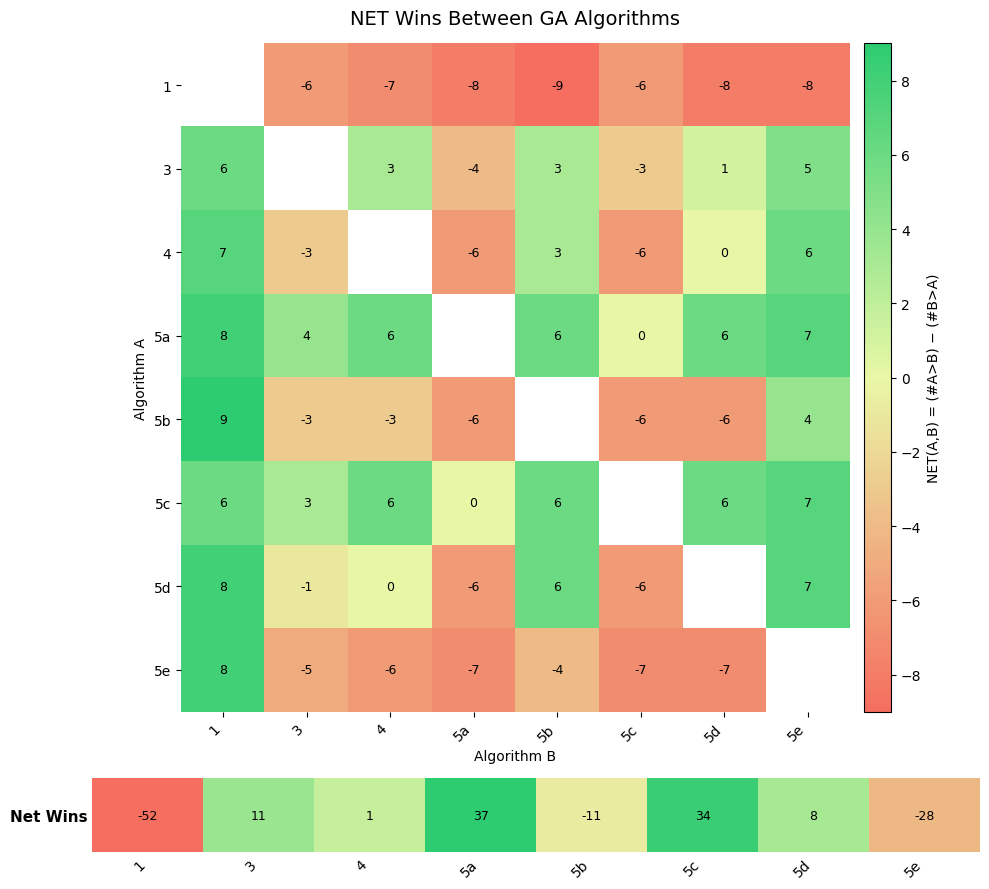

In [512]:
mat_net = build_net_from_summary(summary_holm)
plot_net_matrix_only_wins_bottom(mat_net, ALGO_ORDER, "NET Wins Between GA Algorithms")


### Symmetric Prices

In [513]:
def build_win_matrix_standard(df_mannwhitney, algo_order):
    """
    Construye M[A,B] pero SOLO usando los entornos cuyo nombre termine en '_standard'.
    """
    # Filtrar entornos
    df_std = df_mannwhitney[df_mannwhitney["env_name"].str.endswith("_standard")]

    # Agrupar igual que summary_holm, pero solo en standard
    summary_std = (
        df_std.groupby(["algorithm_1", "algorithm_2"])["reject_H0_Holm"]
        .sum()
        .reset_index()
        .rename(columns={"reject_H0_Holm": "envs_where_a1_significantly_better_Holm"})
    )

    # Construir matriz
    mat = pd.DataFrame(0, index=algo_order, columns=algo_order, dtype=float)

    for _, row in summary_std.iterrows():
        a1 = row["algorithm_1"]
        a2 = row["algorithm_2"]
        v  = float(row["envs_where_a1_significantly_better_Holm"])
        if a1 in algo_order and a2 in algo_order:
            mat.loc[a1, a2] = v

    # Solo la diagonal es NaN
    np.fill_diagonal(mat.values, np.nan)
    return mat


In [514]:
ALGO_ORDER = ["1", "3", "4", "5a", "5b", "5c", "5d", "5e"]

win_mat_standard = build_win_matrix_standard(df_mannwhitney, ALGO_ORDER)

In [515]:
colors = {
    "main":   ["#F56E5F", "#E9F8A6", "#2ECC71"], 
    "wins":   ["#E8F8F5", "#27AE60"],             
    "losses": ["#FDEDEC", "#F56E5F"],             
}

cmap_main   = LinearSegmentedColormap.from_list("main",   colors["main"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   colors["wins"])
cmap_losses = LinearSegmentedColormap.from_list("losses", colors["losses"])

def _plot_heatmap_with_totals_clean(mat, title):

    # Totales por fila y columna
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(2, 3, width_ratios=[20, 0.8, 2.2],
                   height_ratios=[20, 2.2], figure=fig)

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # Heatmap principal
    im = ax_main.imshow(mat.values, aspect="auto",
                        interpolation="nearest", cmap=cmap_main)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)
    cbar.set_label("# environments A ≻ B (Holm)")

    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: escribir valores incluso si val == 0 ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                ax_main.text(j, i, f"{int(val)}",
                             ha="center", va="center",
                             fontsize=9, color="#1C1C1C")

    # Columna Wins
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold",
                             fontsize=10, rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, f"{int(v)}", ha="center", va="center")

    for sp in ax_wins.spines.values(): sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # Fila Losses
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold", fontsize=10)

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, f"{int(v)}", ha="center", va="center")

    for sp in ax_losses.spines.values(): sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # Separadores
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

    for sp in ax_main.spines.values(): sp.set_visible(False)

    plt.tight_layout()
    plt.show()

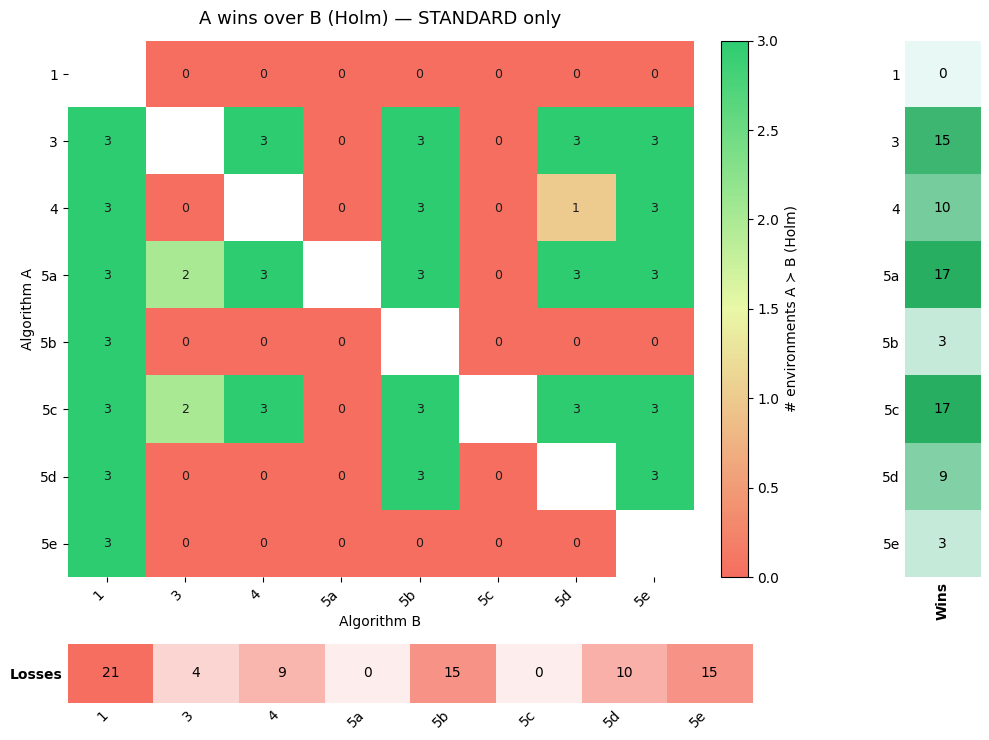

In [516]:
_plot_heatmap_with_totals_clean(win_mat_standard, "A wins over B (Holm) — STANDARD only")

In [517]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# Paletas (las “bonitas”)
cmap_main   = LinearSegmentedColormap.from_list("green_red", ["#CDFADF", "#8ECEA8", "#27AE60"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   ["#CDFADF", "#8ECEA8", "#27AE60"])
cmap_losses = LinearSegmentedColormap.from_list("losses", ["#FDEDEC", "#F56E5F"])


def _plot_heatmap_green(mat, title):
    # Totales
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    # Normalizador independiente
    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(
        2, 3,
        width_ratios=[20, 0.8, 2.2],
        height_ratios=[20, 2.2],
        figure=fig
    )

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # === Heatmap principal ===
    im = ax_main.imshow(mat.values, aspect="auto", interpolation="nearest", cmap=cmap_main)

    # === Colorbar al lado de Wins ===
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_wins)
    cax = divider.append_axes("right", size="7%", pad=0.1)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("# environments A ≻ B (Holm)")

    # Etiquetas
    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: mostrar ceros correctamente ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):          # <-- CORREGIDO
                ax_main.text(
                    j, i, f"{int(val)}",
                    ha="center", va="center",
                    fontsize=9, color="#1C1C1C"
                )

    # === Sección WINS ===
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", interpolation="nearest", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold", rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, str(int(v)), ha="center", va="center")

    for sp in ax_wins.spines.values():
        sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # === Sección LOSSES ===
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", interpolation="nearest", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold")

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, str(int(v)), ha="center", va="center")

    for sp in ax_losses.spines.values():
        sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # === Separadores blancos ===
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([])
        ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)

    # Sin bordes
    for sp in ax_main.spines.values():
        sp.set_visible(False)

    plt.tight_layout()
    plt.show()


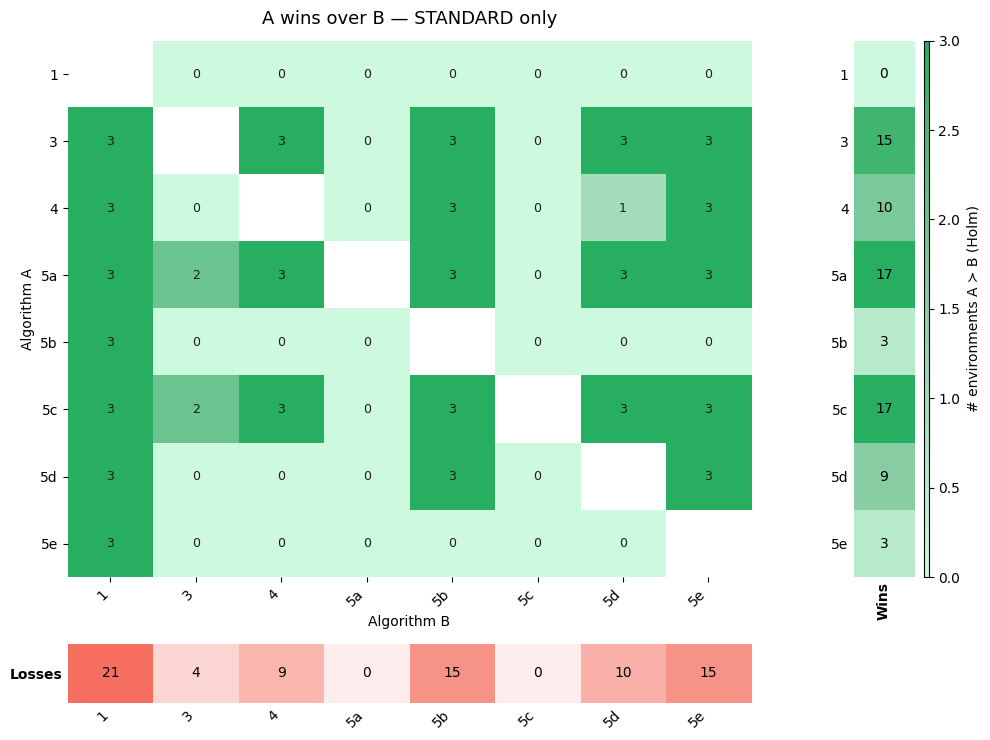

In [518]:
_plot_heatmap_green(win_mat_standard, "A wins over B — STANDARD only")

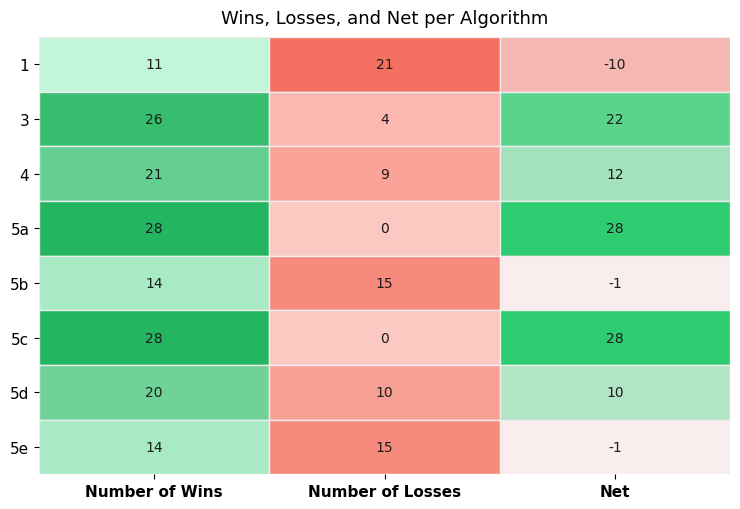

In [519]:
# --- 1. Filtrar solo entornos *_standard ---
summary_holm_standard = (
    df_mannwhitney[df_mannwhitney["env_name"].str.contains("_standard")]
    .groupby(["algorithm_1", "algorithm_2"])["reject_H0_Holm"]
    .sum()
    .reset_index()
    .rename(columns={"reject_H0_Holm": "envs_where_a1_significantly_better_Holm"})
)

# --- 2. Normalizar ---
df_best_norm_standard = _normalize_summary_df(summary_holm_standard)

# --- 3. Construir tabla wins/losses ---
summary_table_standard = _compute_wins_losses(df_best_norm_standard)

# --- 4. Plotear ---
_plot_wins_losses_net_table(summary_table_standard)


In [520]:
def build_net_from_summary_standard(df_mannwhitney, algo_order):
    """
    Construye matriz NET usando SOLO entornos *_standard.

    NET[A,B] = (# standard donde A > B) - (# standard donde B > A)
    """

    # -----------------------------
    # 1. Validaciones
    # -----------------------------
    required_cols = {"env_name", "algorithm_1", "algorithm_2", "reject_H0_Holm"}
    missing = required_cols - set(df_mannwhitney.columns)
    if missing:
        raise ValueError(f"df_mannwhitney le faltan columnas: {missing}")

    # -----------------------------
    # 2. Filtrar SOLO *_standard
    # -----------------------------
    df_std = df_mannwhitney[df_mannwhitney["env_name"].str.endswith("standard")]

    if df_std.empty:
        print("⚠️ Advertencia: No hay entornos *_standard en df_mannwhitney.")
        # devolver matriz vacía pero bien formada
        return pd.DataFrame(np.nan, index=algo_order, columns=algo_order)

    # -----------------------------
    # 3. Agrupar por pares A>B
    # -----------------------------
    grouped = (
        df_std.groupby(["algorithm_1", "algorithm_2"])["reject_H0_Holm"]
        .sum()
        .reset_index()
        .rename(columns={"reject_H0_Holm": "wins_A_over_B"})
    )

    # -----------------------------
    # 4. Matriz cruda A>B en orden dado
    # -----------------------------
    algos = algo_order[:]  # copiar el orden explícito del usuario

    mat_raw = pd.DataFrame(0, index=algos, columns=algos, dtype=int)

    for _, row in grouped.iterrows():
        a1, a2, v = row["algorithm_1"], row["algorithm_2"], int(row["wins_A_over_B"])
        if a1 in algos and a2 in algos:
            mat_raw.loc[a1, a2] = v

    # -----------------------------
    # 5. Construir NET = mat[A,B] - mat[B,A]
    # -----------------------------
    mat_net = pd.DataFrame(np.nan, index=algos, columns=algos)

    for a in algos:
        for b in algos:
            if a != b:
                mat_net.loc[a, b] = mat_raw.loc[a, b] - mat_raw.loc[b, a]

    return mat_net


In [521]:
def plot_net_matrix_only_wins_bottom_standard(
    mat_net,
    algo_order,
    title,
    cmap_main=cmap_net,
    cmap_wins=cmap_wins
):
    """
    Heatmap NET (arriba) + NET WINS horizontal (abajo),
    usando SIEMPRE la paleta GLOBAL_COLORS.
    Especial para entornos *_standard*.
    """

    # ----------------------------------------
    # Reordenar según ALGO_ORDER
    # ----------------------------------------
    mat_net = mat_net.loc[algo_order, algo_order]

    # ----------------------------------------
    # NET WINS (suma por fila)
    # ----------------------------------------
    wins = mat_net.sum(axis=1, skipna=True).astype(int)

    # Normalización
    def norm01(arr):
        arr = np.asarray(arr, float)
        if arr.max() == arr.min():
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n = norm01(wins)

    # ----------------------------------------
    # LAYOUT
    # ----------------------------------------
    fig = plt.figure(figsize=(10, 9))
    gs = GridSpec(2, 1, height_ratios=[20, 2.2], figure=fig)

    ax_main = fig.add_subplot(gs[0, 0])
    ax_wins = fig.add_subplot(gs[1, 0])

    # ----------------------------------------
    # HEATMAP PRINCIPAL
    # ----------------------------------------
    vmax = np.nanmax(np.abs(mat_net.values))

    im = ax_main.imshow(
        mat_net.values,
        cmap=cmap_main,
        vmin=-vmax,
        vmax=vmax
    )

    # Colorbar
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_main)
    cax = divider.append_axes("right", size="4%", pad=0.15)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("NET(A,B) = (#A>B) − (#B>A)", fontsize=10)

    # Etiquetas
    ax_main.set_xticks(np.arange(mat_net.shape[1]))
    ax_main.set_yticks(np.arange(mat_net.shape[0]))
    ax_main.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat_net.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=14, pad=14)

    # Numeritos en cada celda
    for i in range(mat_net.shape[0]):
        for j in range(mat_net.shape[1]):
            v = mat_net.iloc[i, j]
            if not np.isnan(v):
                ax_main.text(j, i, str(int(v)), ha="center", va="center", fontsize=9)

    for sp in ax_main.spines.values():
        sp.set_visible(False)

    # ----------------------------------------
    # FILA INFERIOR: NET WINS
    # ----------------------------------------
    wins_img = wins_n.reshape(1, len(wins))
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)

    ax_wins.set_xticks(np.arange(len(wins)))
    ax_wins.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_wins.set_yticks([0])
    ax_wins.set_yticklabels(["Net Wins"], fontsize=11, fontweight="bold")

    for j, v in enumerate(wins):
        ax_wins.text(j, 0, str(int(v)), ha="center", va="center", fontsize=9)

    for sp in ax_wins.spines.values():
        sp.set_visible(False)

    ax_wins.tick_params(length=0)

    plt.tight_layout()
    plt.show()



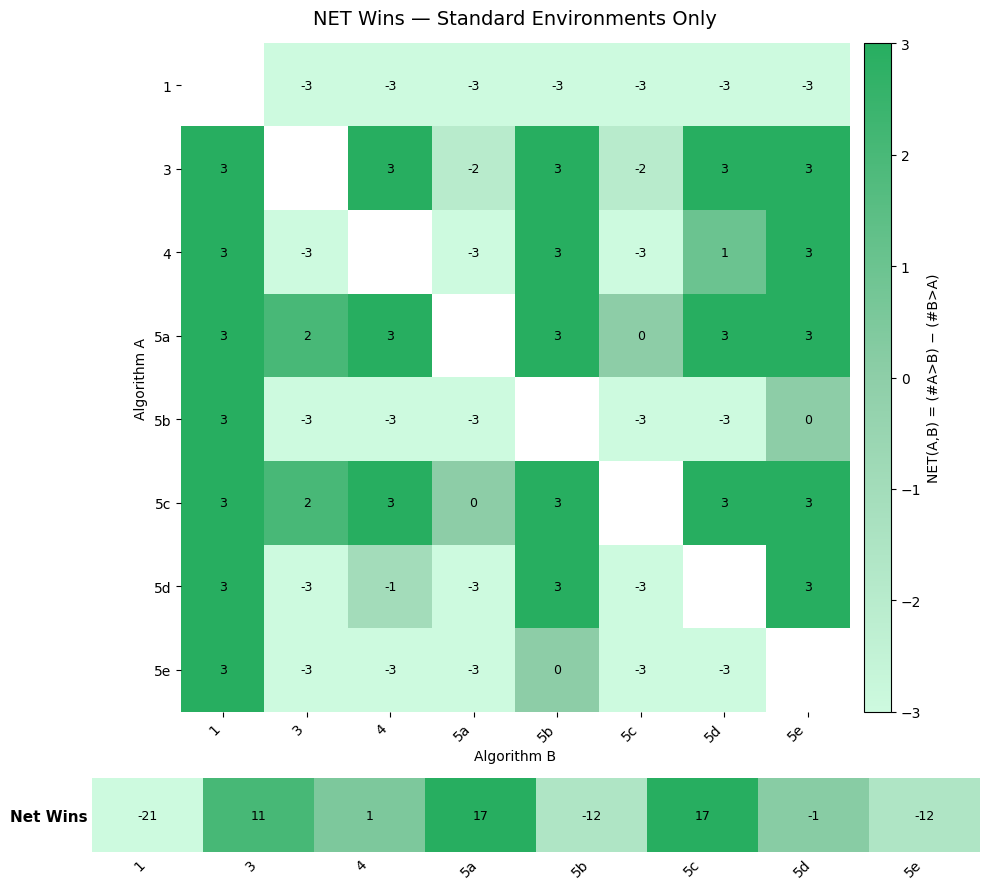

In [522]:
mat_net_standard = build_net_from_summary_standard(df_mannwhitney, ALGO_ORDER)

plot_net_matrix_standard_only_wins(
    mat_net_standard,
    ALGO_ORDER,
    "NET Wins — Standard Environments Only"
)

### Perturbed

In [523]:
def build_win_matrix_perturbed(df_mannwhitney, algo_order):
    """
    Construye M[A,B] pero SOLO usando los entornos cuyo nombre termine en '_perturbed'.
    """
    # Filtrar entornos
    df_perturbed = df_mannwhitney[df_mannwhitney["env_name"].str.endswith("_perturbed")]

    # Agrupar igual que summary_holm, pero solo en perturbed
    summary_perturbed = (
        df_perturbed.groupby(["algorithm_1", "algorithm_2"])["reject_H0_Holm"]
        .sum()
        .reset_index()
        .rename(columns={"reject_H0_Holm": "envs_where_a1_significantly_better_Holm"})
    )

    # Construir matriz
    mat = pd.DataFrame(0, index=algo_order, columns=algo_order, dtype=float)

    for _, row in summary_perturbed.iterrows():
        a1 = row["algorithm_1"]
        a2 = row["algorithm_2"]
        v  = float(row["envs_where_a1_significantly_better_Holm"])
        if a1 in algo_order and a2 in algo_order:
            mat.loc[a1, a2] = v

    # Solo la diagonal es NaN
    np.fill_diagonal(mat.values, np.nan)
    return mat

In [524]:
ALGO_ORDER = ["1", "3", "4", "5a", "5b", "5c", "5d", "5e"]

win_matrix_perturbed = build_win_matrix_perturbed(df_mannwhitney, ALGO_ORDER)

In [525]:
colors = {
    "main":   ["#F56E5F", "#E9F8A6", "#2ECC71"], 
    "wins":   ["#E8F8F5", "#27AE60"],             
    "losses": ["#FDEDEC", "#F56E5F"],             
}

cmap_main   = LinearSegmentedColormap.from_list("main",   colors["main"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   colors["wins"])
cmap_losses = LinearSegmentedColormap.from_list("losses", colors["losses"])

def _plot_heatmap_with_totals_clean(mat, title):

    # Totales por fila y columna
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(2, 3, width_ratios=[20, 0.8, 2.2],
                   height_ratios=[20, 2.2], figure=fig)

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # Heatmap principal
    im = ax_main.imshow(mat.values, aspect="auto",
                        interpolation="nearest", cmap=cmap_main)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)
    cbar.set_label("# environments A ≻ B (Holm)")

    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: escribir valores incluso si val == 0 ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                ax_main.text(j, i, f"{int(val)}",
                             ha="center", va="center",
                             fontsize=9, color="#1C1C1C")

    # Columna Wins
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold",
                             fontsize=10, rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, f"{int(v)}", ha="center", va="center")

    for sp in ax_wins.spines.values(): sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # Fila Losses
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold", fontsize=10)

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, f"{int(v)}", ha="center", va="center")

    for sp in ax_losses.spines.values(): sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # Separadores
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

    for sp in ax_main.spines.values(): sp.set_visible(False)

    plt.tight_layout()
    plt.show()

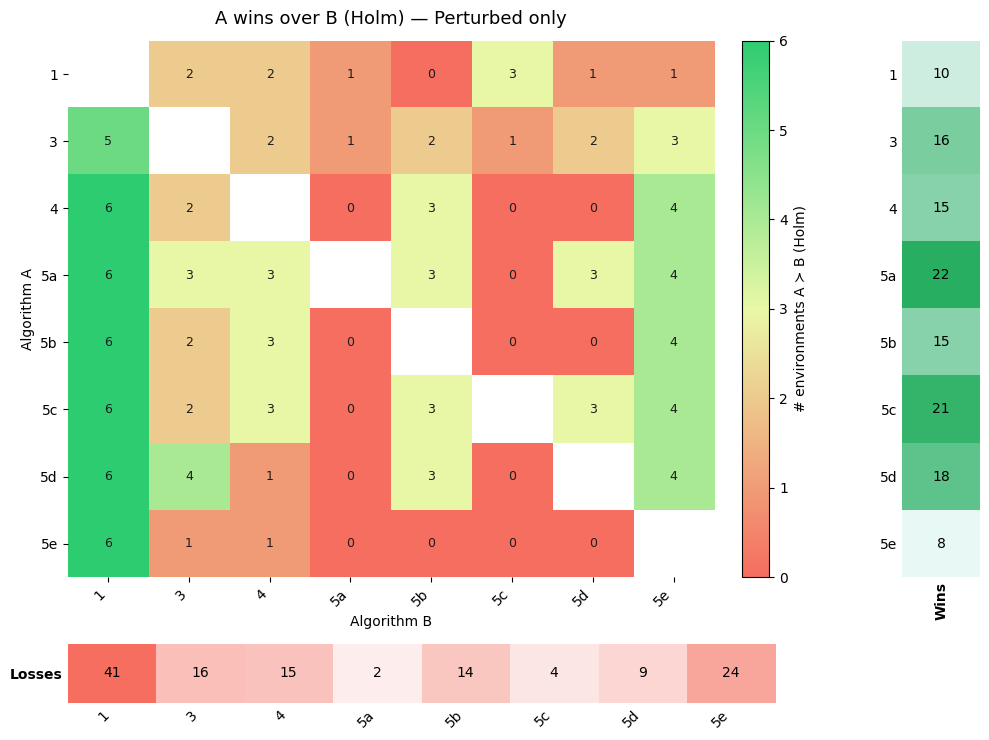

In [526]:
_plot_heatmap_with_totals_clean(win_matrix_perturbed, "A wins over B (Holm) — Perturbed only")

In [527]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# Paletas (las “bonitas”)
cmap_main   = LinearSegmentedColormap.from_list("green_red", ["#E9FFDE", "#7EE6A7", "#27AE60"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   ["#CDFADF", "#8ECEA8", "#27AE60"])
cmap_losses = LinearSegmentedColormap.from_list("losses", ["#F8DBD9", "#FF796A", "#F15746"])


def _plot_heatmap_green(mat, title):
    # Totales
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    # Normalizador independiente
    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(
        2, 3,
        width_ratios=[20, 0.8, 2.2],
        height_ratios=[20, 2.2],
        figure=fig
    )

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # === Heatmap principal ===
    im = ax_main.imshow(mat.values, aspect="auto", interpolation="nearest", cmap=cmap_main)

    # === Colorbar al lado de Wins ===
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_wins)
    cax = divider.append_axes("right", size="7%", pad=0.1)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("# environments A ≻ B (Holm)")

    # Etiquetas
    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: mostrar ceros correctamente ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):          # <-- CORREGIDO
                ax_main.text(
                    j, i, f"{int(val)}",
                    ha="center", va="center",
                    fontsize=9, color="#1C1C1C"
                )

    # === Sección WINS ===
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", interpolation="nearest", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold", rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, str(int(v)), ha="center", va="center")

    for sp in ax_wins.spines.values():
        sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # === Sección LOSSES ===
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", interpolation="nearest", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold")

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, str(int(v)), ha="center", va="center")

    for sp in ax_losses.spines.values():
        sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # === Separadores blancos ===
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([])
        ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)

    # Sin bordes
    for sp in ax_main.spines.values():
        sp.set_visible(False)

    plt.tight_layout()
    plt.show()


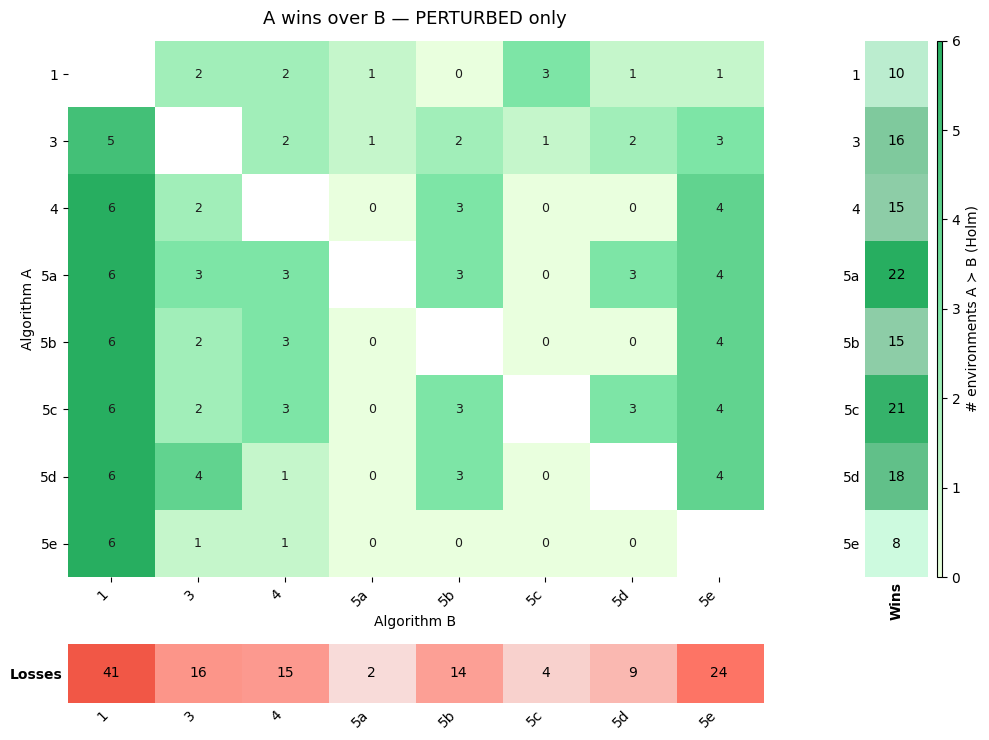

In [528]:
_plot_heatmap_green(win_matrix_perturbed, "A wins over B — PERTURBED only")

In [529]:
def build_net_from_summary_perturbed(df_mannwhitney, algo_order):
    """
    Construye matriz NET usando SOLO entornos *_perturbed.
    
    NET[A,B] = (# envs perturbed donde A > B) - (# envs perturbed donde B > A)
    """

    # ---- 1. Filtrar solo entornos perturbed ----
    df_std = df_mannwhitney[df_mannwhitney["env_name"].str.endswith("perturbed")]

    # ---- 2. Agrupar para obtener # veces A > B ----
    grouped = (
        df_std.groupby(["algorithm_1", "algorithm_2"])["reject_H0_Holm"]
        .sum()
        .reset_index()
        .rename(columns={"reject_H0_Holm": "wins_A_over_B"})
    )

    # ---- 3. Matriz cruda A>B respetando el orden dado ----
    algos = algo_order[:]   # mantener tu orden explícito
    mat_raw = pd.DataFrame(0, index=algos, columns=algos, dtype=int)

    for _, row in grouped.iterrows():
        a1, a2, v = row["algorithm_1"], row["algorithm_2"], int(row["wins_A_over_B"])
        if a1 in algos and a2 in algos:
            mat_raw.loc[a1, a2] = v

    # ---- 4. Construir matriz NET[A,B] = mat[A,B] - mat[B,A] ----
    mat_net = pd.DataFrame(np.nan, index=algos, columns=algos)

    for a in algos:
        for b in algos:
            if a != b:
                mat_net.loc[a, b] = mat_raw.loc[a, b] - mat_raw.loc[b, a]

    return mat_net


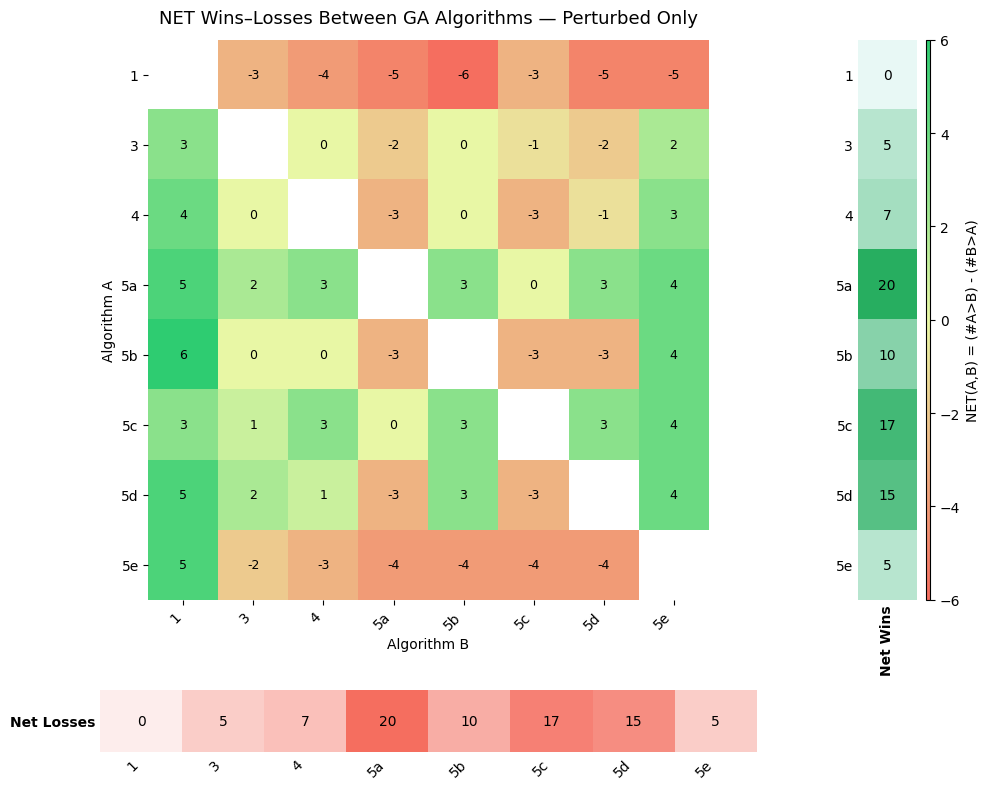

In [530]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ============================================================
# CONFIGURACIÓN PERSONALIZABLE
# ============================================================

# ---- Orden y selección de algoritmos
ALGO_ORDER=ALGO_ORDER

# ---- Colores (CAMBIAR AQUÍ)

cmap_main   = LinearSegmentedColormap.from_list("main",   colors["main"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   colors["wins"])
cmap_losses = LinearSegmentedColormap.from_list("losses", colors["losses"])


# ============================================================
# (A) Construcción de matriz NET
# ============================================================
def build_net_from_summary(summary_holm, algo_order):
    summary = summary_holm[
        summary_holm["algorithm_1"].isin(algo_order)
        & summary_holm["algorithm_2"].isin(algo_order)
    ].copy()

    algos = algo_order[:]  

    mat_raw = pd.DataFrame(0, index=algos, columns=algos)
    for _, row in summary.iterrows():
        a1, a2, v = row["algorithm_1"], row["algorithm_2"], int(row.iloc[2])
        mat_raw.loc[a1, a2] = v

    mat_net = pd.DataFrame(np.nan, index=algos, columns=algos)
    for a in algos:
        for b in algos:
            if a != b:
                mat_net.loc[a, b] = mat_raw.loc[a, b] - mat_raw.loc[b, a]

    return mat_net


# ============================================================
# (B) Plot NET (COLORBAR A LA DERECHA DE NET WINS)
# ============================================================
def plot_net_matrix_perturbed(mat_net, title):

    wins   = mat_net.clip(lower=0).sum(axis=1)
    losses = (-mat_net.clip(upper=0)).sum(axis=0)

    def norm01(arr):
        arr = np.asarray(arr, float)
        return np.zeros_like(arr) if arr.max()==arr.min() else (arr-arr.min())/(arr.max()-arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    fig = plt.figure(figsize=(10, 8))
    gs  = GridSpec(2, 3, width_ratios=[20,0.8,2.2], height_ratios=[20,2.2], figure=fig)

    ax_main    = fig.add_subplot(gs[0,0])
    ax_sep_col = fig.add_subplot(gs[0,1])
    ax_wins    = fig.add_subplot(gs[0,2])
    ax_losses  = fig.add_subplot(gs[1,0])
    ax_sep_crn = fig.add_subplot(gs[1,1])
    ax_sep_bln = fig.add_subplot(gs[1,2])

    vmax = np.nanmax(np.abs(mat_net.values))
    im = ax_main.imshow(mat_net.values, cmap=cmap_main, vmin=-vmax, vmax=vmax)

    # ======================================================
    # ★ COLORBAR A LA DERECHA DE "NET WINS"
    # ======================================================
    divider = make_axes_locatable(ax_wins)
    cax = divider.append_axes("right", size="7%", pad=0.1)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("NET(A,B) = (#A>B) - (#B>A)")

    # Labels del heatmap principal
    ax_main.set_xticks(np.arange(mat_net.shape[1]))
    ax_main.set_yticks(np.arange(mat_net.shape[0]))
    ax_main.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat_net.index, fontsize=10)
    ax_main.set_title(title, fontsize=13, pad=12)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")

    for i in range(mat_net.shape[0]):
        for j in range(mat_net.shape[1]):
            v = mat_net.iloc[i, j]
            if not np.isnan(v):
                ax_main.text(j, i, str(int(v)), ha="center", va="center", fontsize=9)

    # NET WINS
    wins_img = wins_n.reshape(-1,1)
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Net Wins"], rotation=90, fontweight="bold")
    ax_wins.set_yticks(np.arange(len(wins)))
    ax_wins.set_yticklabels(mat_net.index)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, str(int(v)), ha="center", va="center")

    for sp in ax_wins.spines.values(): sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # NET LOSSES
    losses_img = losses_n.reshape(1,-1)
    ax_losses.imshow(losses_img, aspect="auto", cmap=cmap_losses)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Net Losses"], fontweight="bold")
    ax_losses.set_xticks(np.arange(len(losses)))
    ax_losses.set_xticklabels(mat_net.columns, rotation=45, ha="right")

    for j,v in enumerate(losses):
        ax_losses.text(j, 0, str(int(v)), ha="center", va="center")

    for sp in ax_losses.spines.values(): sp.set_visible(False)
    ax_losses.tick_params(length=0)

    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

    for sp in ax_main.spines.values(): sp.set_visible(False)

    plt.tight_layout()
    plt.show()


# ============================================================
# (C) EJECUCIÓN FINAL
# ============================================================
# === Crear matriz NET usando SOLO *_perturbed ===
mat_net_perturbed = build_net_from_summary_perturbed(df_mannwhitney, ALGO_ORDER)

# === Ploteo ===
plot_net_matrix_perturbed(mat_net_perturbed, 
                         "NET Wins–Losses Between GA Algorithms — Perturbed Only")


### 5x5 HEATMAPS

### All environments.

In [531]:
ALGO_ORDER = ["1","3", "4", "5a","5d"]
win_mat = build_win_matrix(summary_holm, ALGO_ORDER)

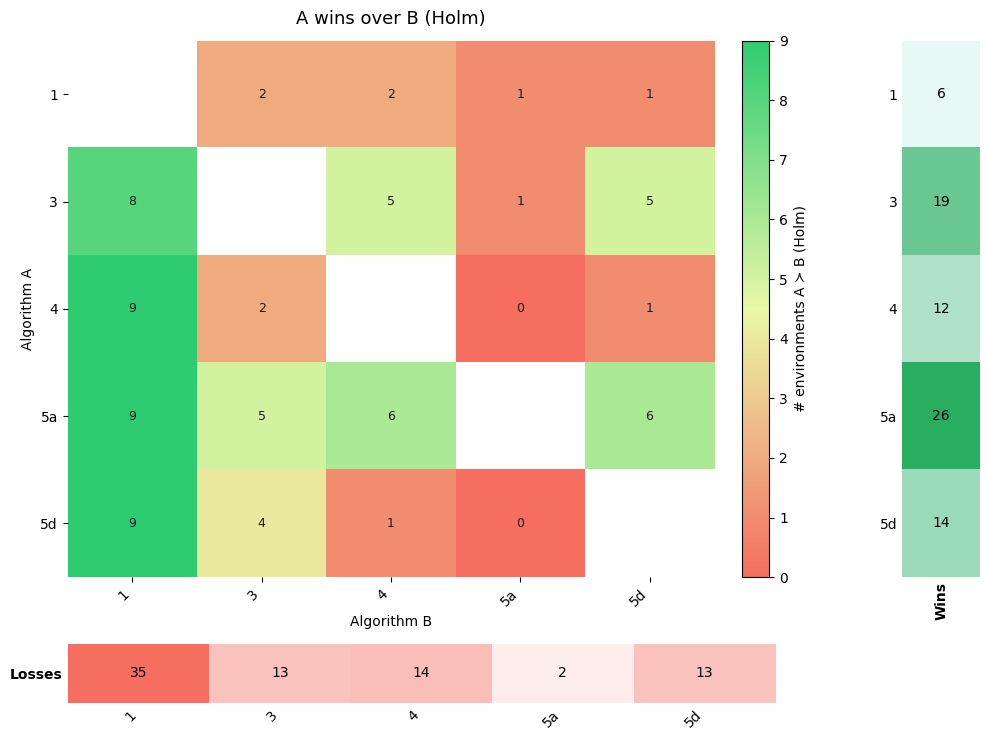

In [546]:
_plot_heatmap_with_totals_clean(win_mat, "A wins over B (Holm)")

In [533]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# Paletas (las “bonitas”)
cmap_main   = LinearSegmentedColormap.from_list("green_red", ["#E9FFDE", "#7EE6A7", "#27AE60"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   ["#CDFADF", "#8ECEA8", "#27AE60"])
cmap_losses = LinearSegmentedColormap.from_list("losses", ["#F8DBD9", "#FF796A", "#F15746"])


def _plot_heatmap_green(mat, title):
    # Totales
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    # Normalizador independiente
    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(
        2, 3,
        width_ratios=[20, 0.8, 2.2],
        height_ratios=[20, 2.2],
        figure=fig
    )

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # === Heatmap principal ===
    im = ax_main.imshow(mat.values, aspect="auto", interpolation="nearest", cmap=cmap_main)

    # === Colorbar al lado de Wins ===
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_wins)
    cax = divider.append_axes("right", size="7%", pad=0.1)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("# environments A ≻ B (Holm)")

    # Etiquetas
    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: mostrar ceros correctamente ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):          # <-- CORREGIDO
                ax_main.text(
                    j, i, f"{int(val)}",
                    ha="center", va="center",
                    fontsize=9, color="#1C1C1C"
                )

    # === Sección WINS ===
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", interpolation="nearest", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold", rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, str(int(v)), ha="center", va="center")

    for sp in ax_wins.spines.values():
        sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # === Sección LOSSES ===
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", interpolation="nearest", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold")

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, str(int(v)), ha="center", va="center")

    for sp in ax_losses.spines.values():
        sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # === Separadores blancos ===
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([])
        ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)

    # Sin bordes
    for sp in ax_main.spines.values():
        sp.set_visible(False)

    plt.tight_layout()
    plt.show()


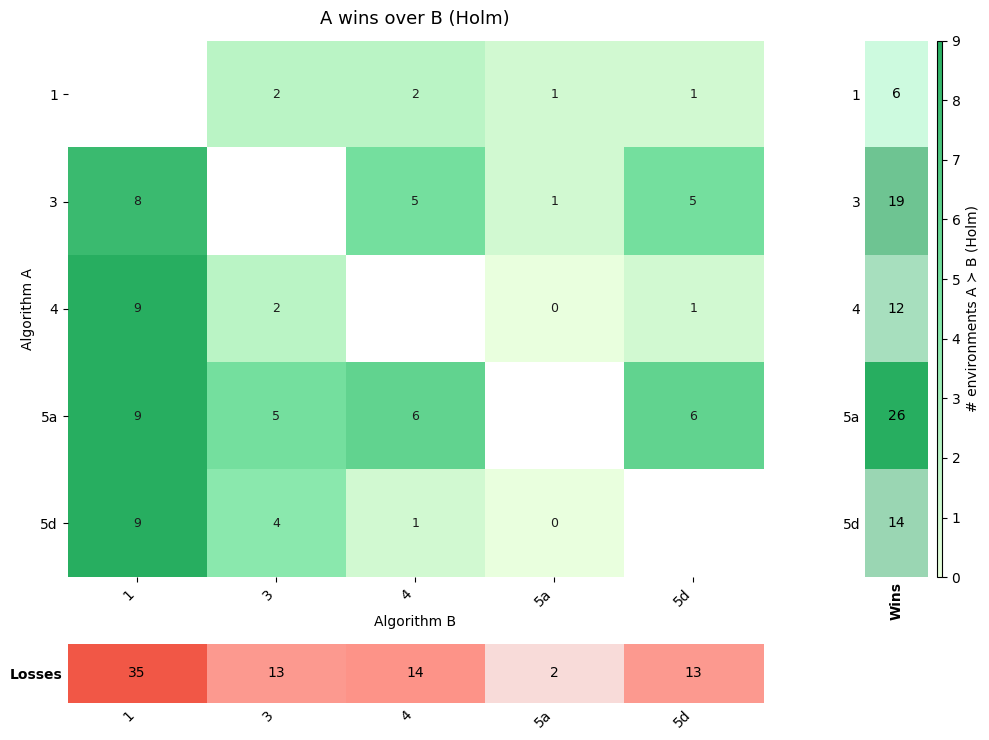

In [534]:
_plot_heatmap_green(win_mat, "A wins over B (Holm)")

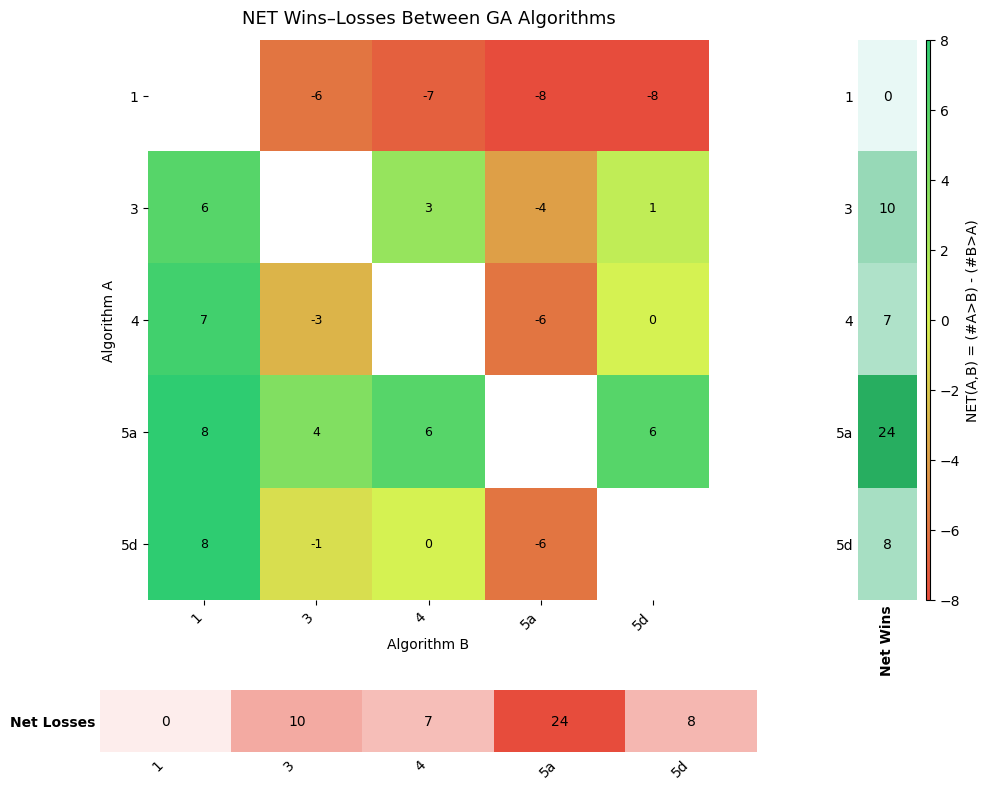

In [535]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ============================================================
# CONFIGURACIÓN PERSONALIZABLE
# ============================================================

# ---- Orden y selección de algoritmos
ALGO_ORDER = ALGO_ORDER

# ---- Colores (CAMBIAR AQUÍ)
colors = {
    "main":   ["#E74C3C", "#D6F352", "#2ECC71"], 
    "wins":   ["#E8F8F5", "#27AE60"],             
    "losses": ["#FDEDEC", "#E74C3C"],             
}

cmap_main   = LinearSegmentedColormap.from_list("main",   colors["main"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   colors["wins"])
cmap_losses = LinearSegmentedColormap.from_list("losses", colors["losses"])


# ============================================================
# (A) Construcción de matriz NET
# ============================================================
def build_net_from_summary(summary_holm, algo_order):
    summary = summary_holm[
        summary_holm["algorithm_1"].isin(algo_order)
        & summary_holm["algorithm_2"].isin(algo_order)
    ].copy()

    algos = algo_order[:]  

    mat_raw = pd.DataFrame(0, index=algos, columns=algos)
    for _, row in summary.iterrows():
        a1, a2, v = row["algorithm_1"], row["algorithm_2"], int(row.iloc[2])
        mat_raw.loc[a1, a2] = v

    mat_net = pd.DataFrame(np.nan, index=algos, columns=algos)
    for a in algos:
        for b in algos:
            if a != b:
                mat_net.loc[a, b] = mat_raw.loc[a, b] - mat_raw.loc[b, a]

    return mat_net


# ============================================================
# (B) Plot NET (COLORBAR A LA DERECHA DE NET WINS)
# ============================================================
def plot_net_matrix(mat_net, title):

    wins   = mat_net.clip(lower=0).sum(axis=1)
    losses = (-mat_net.clip(upper=0)).sum(axis=0)

    def norm01(arr):
        arr = np.asarray(arr, float)
        return np.zeros_like(arr) if arr.max()==arr.min() else (arr-arr.min())/(arr.max()-arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    fig = plt.figure(figsize=(10, 8))
    gs  = GridSpec(2, 3, width_ratios=[20,0.8,2.2], height_ratios=[20,2.2], figure=fig)

    ax_main    = fig.add_subplot(gs[0,0])
    ax_sep_col = fig.add_subplot(gs[0,1])
    ax_wins    = fig.add_subplot(gs[0,2])
    ax_losses  = fig.add_subplot(gs[1,0])
    ax_sep_crn = fig.add_subplot(gs[1,1])
    ax_sep_bln = fig.add_subplot(gs[1,2])

    vmax = np.nanmax(np.abs(mat_net.values))
    im = ax_main.imshow(mat_net.values, cmap=cmap_main, vmin=-vmax, vmax=vmax)

    # ======================================================
    # ★ COLORBAR A LA DERECHA DE "NET WINS"
    # ======================================================
    divider = make_axes_locatable(ax_wins)
    cax = divider.append_axes("right", size="7%", pad=0.1)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("NET(A,B) = (#A>B) - (#B>A)")

    # Labels del heatmap principal
    ax_main.set_xticks(np.arange(mat_net.shape[1]))
    ax_main.set_yticks(np.arange(mat_net.shape[0]))
    ax_main.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat_net.index, fontsize=10)
    ax_main.set_title(title, fontsize=13, pad=12)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")

    for i in range(mat_net.shape[0]):
        for j in range(mat_net.shape[1]):
            v = mat_net.iloc[i, j]
            if not np.isnan(v):
                ax_main.text(j, i, str(int(v)), ha="center", va="center", fontsize=9)

    # NET WINS
    wins_img = wins_n.reshape(-1,1)
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Net Wins"], rotation=90, fontweight="bold")
    ax_wins.set_yticks(np.arange(len(wins)))
    ax_wins.set_yticklabels(mat_net.index)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, str(int(v)), ha="center", va="center")

    for sp in ax_wins.spines.values(): sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # NET LOSSES
    losses_img = losses_n.reshape(1,-1)
    ax_losses.imshow(losses_img, aspect="auto", cmap=cmap_losses)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Net Losses"], fontweight="bold")
    ax_losses.set_xticks(np.arange(len(losses)))
    ax_losses.set_xticklabels(mat_net.columns, rotation=45, ha="right")

    for j,v in enumerate(losses):
        ax_losses.text(j, 0, str(int(v)), ha="center", va="center")

    for sp in ax_losses.spines.values(): sp.set_visible(False)
    ax_losses.tick_params(length=0)

    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

    for sp in ax_main.spines.values(): sp.set_visible(False)

    plt.tight_layout()
    plt.show()


# ============================================================
# (C) EJECUCIÓN FINAL
# ============================================================
mat_net = build_net_from_summary(summary_holm, ALGO_ORDER)
plot_net_matrix(mat_net, "NET Wins–Losses Between GA Algorithms")


### Symmetric Prices.

In [541]:
win_mat_standard = build_win_matrix_standard(df_mannwhitney, ALGO_ORDER)

In [542]:
colors = {
    "main":   ["#F56E5F", "#E9F8A6", "#2ECC71"], 
    "wins":   ["#E8F8F5", "#27AE60"],             
    "losses": ["#FDEDEC", "#F56E5F"],             
}

cmap_main   = LinearSegmentedColormap.from_list("main",   colors["main"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   colors["wins"])
cmap_losses = LinearSegmentedColormap.from_list("losses", colors["losses"])

def _plot_heatmap_with_totals_clean(mat, title):

    # Totales por fila y columna
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(2, 3, width_ratios=[20, 0.8, 2.2],
                   height_ratios=[20, 2.2], figure=fig)

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # Heatmap principal
    im = ax_main.imshow(mat.values, aspect="auto",
                        interpolation="nearest", cmap=cmap_main)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)
    cbar.set_label("# environments A ≻ B (Holm)")

    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: escribir valores incluso si val == 0 ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                ax_main.text(j, i, f"{int(val)}",
                             ha="center", va="center",
                             fontsize=9, color="#1C1C1C")

    # Columna Wins
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold",
                             fontsize=10, rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, f"{int(v)}", ha="center", va="center")

    for sp in ax_wins.spines.values(): sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # Fila Losses
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold", fontsize=10)

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, f"{int(v)}", ha="center", va="center")

    for sp in ax_losses.spines.values(): sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # Separadores
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

    for sp in ax_main.spines.values(): sp.set_visible(False)

    plt.tight_layout()
    plt.show()

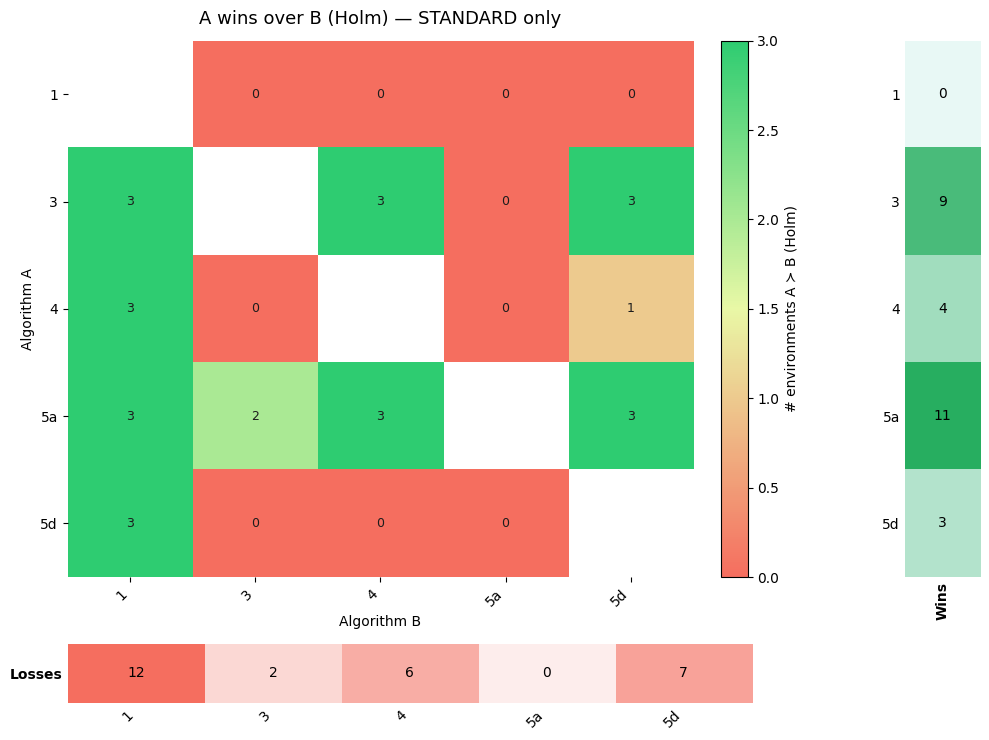

In [543]:
_plot_heatmap_with_totals_clean(win_mat_standard, "A wins over B (Holm) — STANDARD only")

In [538]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# Paletas (las “bonitas”)
cmap_main   = LinearSegmentedColormap.from_list("green_red", ["#E9FFDE", "#7EE6A7", "#27AE60"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   ["#CDFADF", "#8ECEA8", "#27AE60"])
cmap_losses = LinearSegmentedColormap.from_list("losses", ["#F8DBD9", "#FF796A", "#F15746"])


def _plot_heatmap_green(mat, title):
    # Totales
    wins   = mat.sum(axis=1, skipna=True).astype(int)
    losses = mat.sum(axis=0, skipna=True).astype(int)

    # Normalizador independiente
    def norm01(arr):
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0 or np.all(arr == arr[0]):
            return np.zeros_like(arr)
        return (arr - arr.min()) / (arr.max() - arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    # Layout
    fig = plt.figure(figsize=(10, 7.5))
    gs  = GridSpec(
        2, 3,
        width_ratios=[20, 0.8, 2.2],
        height_ratios=[20, 2.2],
        figure=fig
    )

    ax_main    = fig.add_subplot(gs[0, 0])
    ax_sep_col = fig.add_subplot(gs[0, 1])
    ax_wins    = fig.add_subplot(gs[0, 2])
    ax_losses  = fig.add_subplot(gs[1, 0])
    ax_sep_crn = fig.add_subplot(gs[1, 1])
    ax_sep_bln = fig.add_subplot(gs[1, 2])

    # === Heatmap principal ===
    im = ax_main.imshow(mat.values, aspect="auto", interpolation="nearest", cmap=cmap_main)

    # === Colorbar al lado de Wins ===
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_wins)
    cax = divider.append_axes("right", size="7%", pad=0.1)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("# environments A ≻ B (Holm)")

    # Etiquetas
    ax_main.set_xticks(np.arange(mat.shape[1]))
    ax_main.set_yticks(np.arange(mat.shape[0]))
    ax_main.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat.index, fontsize=10)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")
    ax_main.set_title(title, fontsize=13, pad=12)

    # === CORRECCIÓN: mostrar ceros correctamente ===
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if not np.isnan(val):          # <-- CORREGIDO
                ax_main.text(
                    j, i, f"{int(val)}",
                    ha="center", va="center",
                    fontsize=9, color="#1C1C1C"
                )

    # === Sección WINS ===
    wins_img = wins_n.reshape(-1, 1)
    ax_wins.imshow(wins_img, aspect="auto", interpolation="nearest", cmap=cmap_wins)
    ax_wins.set_yticks(np.arange(mat.shape[0]))
    ax_wins.set_yticklabels(mat.index, fontsize=10)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Wins"], fontweight="bold", rotation=90)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, str(int(v)), ha="center", va="center")

    for sp in ax_wins.spines.values():
        sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # === Sección LOSSES ===
    losses_img = losses_n.reshape(1, -1)
    ax_losses.imshow(losses_img, aspect="auto", interpolation="nearest", cmap=cmap_losses)
    ax_losses.set_xticks(np.arange(mat.shape[1]))
    ax_losses.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=10)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Losses"], fontweight="bold")

    for j, v in enumerate(losses):
        ax_losses.text(j, 0, str(int(v)), ha="center", va="center")

    for sp in ax_losses.spines.values():
        sp.set_visible(False)
    ax_losses.tick_params(length=0)

    # === Separadores blancos ===
    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([])
        ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)

    # Sin bordes
    for sp in ax_main.spines.values():
        sp.set_visible(False)

    plt.tight_layout()
    plt.show()


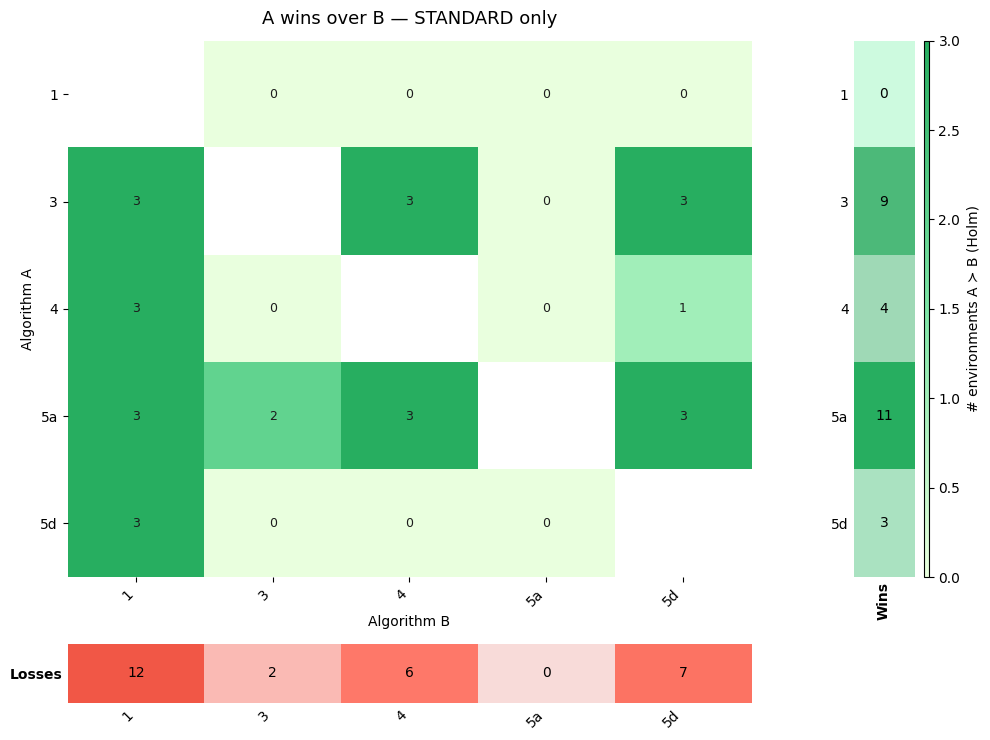

In [539]:
_plot_heatmap_green(win_mat_standard, "A wins over B — STANDARD only")

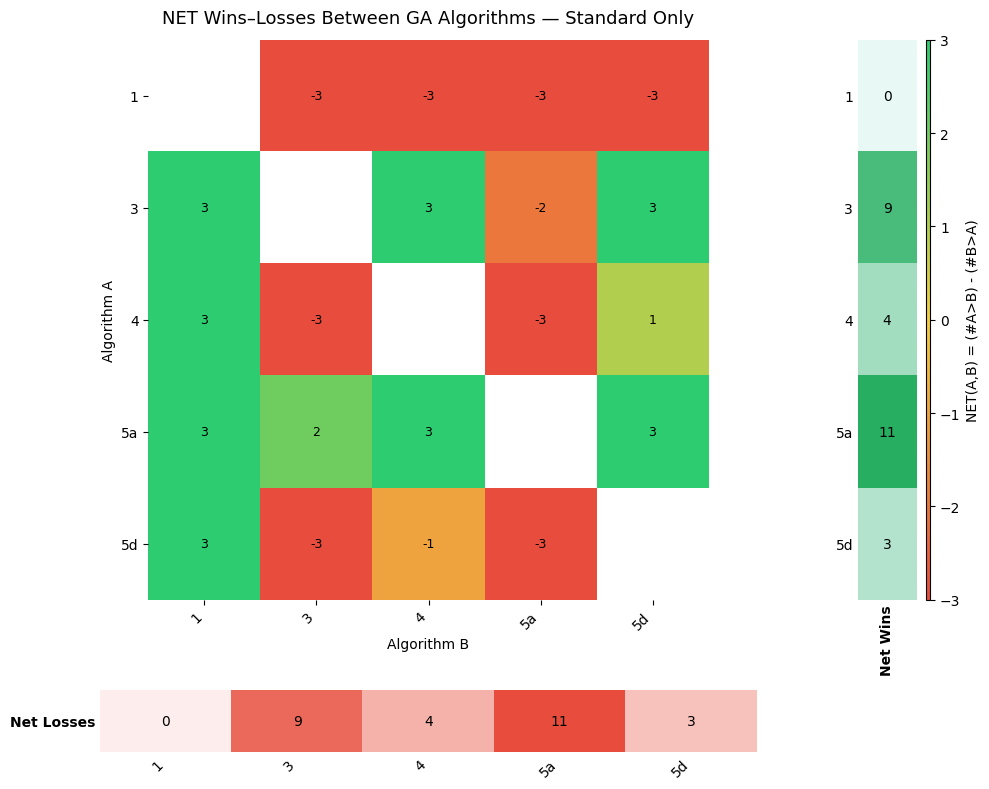

In [540]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ============================================================
# CONFIGURACIÓN PERSONALIZABLE
# ============================================================

# ---- Orden y selección de algoritmos
ALGO_ORDER=ALGO_ORDER

# ---- Colores (CAMBIAR AQUÍ)
colors = {
    "main":   ["#E74C3C", "#F4D03F", "#2ECC71"], 
    "wins":   ["#E8F8F5", "#27AE60"],             
    "losses": ["#FDEDEC", "#E74C3C"],             
}

cmap_main   = LinearSegmentedColormap.from_list("main",   colors["main"])
cmap_wins   = LinearSegmentedColormap.from_list("wins",   colors["wins"])
cmap_losses = LinearSegmentedColormap.from_list("losses", colors["losses"])


# ============================================================
# (A) Construcción de matriz NET
# ============================================================
def build_net_from_summary(summary_holm, algo_order):
    summary = summary_holm[
        summary_holm["algorithm_1"].isin(algo_order)
        & summary_holm["algorithm_2"].isin(algo_order)
    ].copy()

    algos = algo_order[:]  

    mat_raw = pd.DataFrame(0, index=algos, columns=algos)
    for _, row in summary.iterrows():
        a1, a2, v = row["algorithm_1"], row["algorithm_2"], int(row.iloc[2])
        mat_raw.loc[a1, a2] = v

    mat_net = pd.DataFrame(np.nan, index=algos, columns=algos)
    for a in algos:
        for b in algos:
            if a != b:
                mat_net.loc[a, b] = mat_raw.loc[a, b] - mat_raw.loc[b, a]

    return mat_net


# ============================================================
# (B) Plot NET (COLORBAR A LA DERECHA DE NET WINS)
# ============================================================
def plot_net_matrix_standard(mat_net, title):

    wins   = mat_net.clip(lower=0).sum(axis=1)
    losses = (-mat_net.clip(upper=0)).sum(axis=0)

    def norm01(arr):
        arr = np.asarray(arr, float)
        return np.zeros_like(arr) if arr.max()==arr.min() else (arr-arr.min())/(arr.max()-arr.min())

    wins_n   = norm01(wins)
    losses_n = norm01(losses)

    fig = plt.figure(figsize=(10, 8))
    gs  = GridSpec(2, 3, width_ratios=[20,0.8,2.2], height_ratios=[20,2.2], figure=fig)

    ax_main    = fig.add_subplot(gs[0,0])
    ax_sep_col = fig.add_subplot(gs[0,1])
    ax_wins    = fig.add_subplot(gs[0,2])
    ax_losses  = fig.add_subplot(gs[1,0])
    ax_sep_crn = fig.add_subplot(gs[1,1])
    ax_sep_bln = fig.add_subplot(gs[1,2])

    vmax = np.nanmax(np.abs(mat_net.values))
    im = ax_main.imshow(mat_net.values, cmap=cmap_main, vmin=-vmax, vmax=vmax)

    # ======================================================
    # ★ COLORBAR A LA DERECHA DE "NET WINS"
    # ======================================================
    divider = make_axes_locatable(ax_wins)
    cax = divider.append_axes("right", size="7%", pad=0.1)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("NET(A,B) = (#A>B) - (#B>A)")

    # Labels del heatmap principal
    ax_main.set_xticks(np.arange(mat_net.shape[1]))
    ax_main.set_yticks(np.arange(mat_net.shape[0]))
    ax_main.set_xticklabels(mat_net.columns, rotation=45, ha="right", fontsize=10)
    ax_main.set_yticklabels(mat_net.index, fontsize=10)
    ax_main.set_title(title, fontsize=13, pad=12)
    ax_main.set_xlabel("Algorithm B")
    ax_main.set_ylabel("Algorithm A")

    for i in range(mat_net.shape[0]):
        for j in range(mat_net.shape[1]):
            v = mat_net.iloc[i, j]
            if not np.isnan(v):
                ax_main.text(j, i, str(int(v)), ha="center", va="center", fontsize=9)

    # NET WINS
    wins_img = wins_n.reshape(-1,1)
    ax_wins.imshow(wins_img, aspect="auto", cmap=cmap_wins)
    ax_wins.set_xticks([0])
    ax_wins.set_xticklabels(["Net Wins"], rotation=90, fontweight="bold")
    ax_wins.set_yticks(np.arange(len(wins)))
    ax_wins.set_yticklabels(mat_net.index)

    for i, v in enumerate(wins):
        ax_wins.text(0, i, str(int(v)), ha="center", va="center")

    for sp in ax_wins.spines.values(): sp.set_visible(False)
    ax_wins.tick_params(length=0)

    # NET LOSSES
    losses_img = losses_n.reshape(1,-1)
    ax_losses.imshow(losses_img, aspect="auto", cmap=cmap_losses)
    ax_losses.set_yticks([0])
    ax_losses.set_yticklabels(["Net Losses"], fontweight="bold")
    ax_losses.set_xticks(np.arange(len(losses)))
    ax_losses.set_xticklabels(mat_net.columns, rotation=45, ha="right")

    for j,v in enumerate(losses):
        ax_losses.text(j, 0, str(int(v)), ha="center", va="center")

    for sp in ax_losses.spines.values(): sp.set_visible(False)
    ax_losses.tick_params(length=0)

    for ax in (ax_sep_col, ax_sep_crn, ax_sep_bln):
        ax.set_facecolor("white")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

    for sp in ax_main.spines.values(): sp.set_visible(False)

    plt.tight_layout()
    plt.show()


# ============================================================
# (C) EJECUCIÓN FINAL
# ============================================================
# === Crear matriz NET usando SOLO *_standard ===
mat_net_standard = build_net_from_summary_standard(df_mannwhitney, ALGO_ORDER)

# === Ploteo ===
plot_net_matrix_standard(mat_net_standard, 
                         "NET Wins–Losses Between GA Algorithms — Standard Only")
